In [ ]:
import pandas as pd

# Read all sheets into a dictionary of DataFrames
dfs_pqc = pd.read_excel('pqc_recap.xlsx', sheet_name=None)

# Remove 'resource_level_col_name' as it's no longer needed for this approach
# It will be defined inside the loop for each sheet.

In [ ]:
!pip install scikit-posthocs
!pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.6 MB/s eta 0:00:00



- ### Normality Check

  We do normality check per environment per algorithm per operation

- ### Kruskal / Anova [check for significant difference]

  We do this per environment+operation, which mean we try to find significant difference in algorithm with fixed environment+operation wise. Result is showing almost all normality check from previous step are showing some `abnormality`, causing we use `kruskal` on all rows.

- ### Dunn's Posthoc [find pair that have significant difference]

In [ ]:
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scikit_posthocs as sp

# Re-load dfs_pqc for robustness
dfs_pqc = pd.read_excel('pqc_recap.xlsx', sheet_name=None)

# Define the operations columns to analyze (re-defined for robustness)
operations = ['generate_median_time', 'encapsulate_median_time', 'decapsulate_median_time']

# Define the expected resource levels (re-defined for robustness)
resource_levels = ['unconstrained', 'moderate', 'extreme']

# --- Re-calculating Shapiro-Wilk Normality Test for robustness ---
# Initialize a dictionary to store Shapiro-Wilk results
results_shapiro = {}

for level in resource_levels:
    if level not in dfs_pqc:
        # print(f"Warning: Sheet '{level}' not found in 'pqc_recap.xlsx'. Skipping Shapiro-Wilk for this level.")
        continue

    df_level = dfs_pqc[level]

    if df_level.empty:
        # print(f"Warning: No data found for resource level: '{level}'. Skipping Shapiro-Wilk for this level.")
        continue

    results_shapiro[level] = {}

    for operation in operations:
        algorithms = df_level['algorithm'].unique()
        if len(algorithms) == 0:
            continue

        results_shapiro[level][operation] = {}

        for algo in algorithms:
            data = df_level[df_level['algorithm'] == algo][operation].dropna()

            if len(data) < 3:
                results_shapiro[level][operation][algo] = {'W_statistic': None, 'p_value': None, 'message': 'Not enough data points'}
                continue

            try:
                W_stat, p_value_shapiro = stats.shapiro(data)
                results_shapiro[level][operation][algo] = {'W_statistic': W_stat, 'p_value': p_value_shapiro}
            except Exception as e:
                results_shapiro[level][operation][algo] = {'W_statistic': None, 'p_value': None, 'message': f'Error: {e}'}

# --- End of Shapiro-Wilk Re-calculation ---

# Dictionaries to store the final results
final_results_parametric = {}
final_results_non_parametric = {}

print("-- Performing Parametric (ANOVA) or Non-Parametric (Kruskal-Wallis) Tests ---")

# Iterate through each resource level (sheet name)
for level in resource_levels:
    # Check if the sheet exists
    if level not in dfs_pqc:
        print(f"Warning: Sheet '{level}' not found in 'pqc_recap.xlsx'. Skipping analysis for this level.")
        continue

    df_level = dfs_pqc[level]

    if df_level.empty:
        print(f"Warning: No data found for resource level: '{level}'. Skipping analysis for this level.")
        continue

    print(f"\n--- Analyzing for resource level: {level} ---")
    final_results_parametric[level] = {}
    final_results_non_parametric[level] = {}

    for operation in operations:
        print(f"\n  Operation: {operation}")

        # Get unique algorithms for the current resource level and operation
        algorithms_in_data = df_level['algorithm'].unique()

        # Prepare data for testing and normality check
        data_for_test = []
        valid_algorithms_for_op = []
        for algo in algorithms_in_data:
            data = df_level[df_level['algorithm'] == algo][operation].dropna()
            if len(data) > 0:
                data_for_test.append(data)
                valid_algorithms_for_op.append(algo)

        if len(valid_algorithms_for_op) < 2:
            print(f"    Skipping {operation} for '{level}': Not enough valid algorithm groups to compare ({len(valid_algorithms_for_op)}). Need at least 2.")
            continue

        # Determine if data is normally distributed for all groups
        all_normal = True
        for algo in valid_algorithms_for_op:
            if level in results_shapiro and operation in results_shapiro[level] and algo in results_shapiro[level][operation]:
                shapiro_res = results_shapiro[level][operation][algo]
                if shapiro_res['p_value'] is None or shapiro_res['p_value'] < 0.05:
                    all_normal = False
                    break
            else:
                # If Shapiro-Wilk results are missing, assume non-normality for safety or skip
                print(f"      Warning: Shapiro-Wilk result missing for {algo} in {operation} for {level}. Assuming non-normal.")
                all_normal = False
                break

        if all_normal:
            print("    All groups appear normally distributed. Performing One-Way ANOVA.")
            # Prepare DataFrame for ANOVA
            df_anova_op = df_level[df_level['algorithm'].isin(valid_algorithms_for_op)][['algorithm', operation]].dropna()
            df_anova_op['algorithm'] = df_anova_op['algorithm'].astype('category')

            if df_anova_op.empty:
                print(f"      Skipping ANOVA for {operation}: No data available after dropping NaNs.")
                continue

            formula = f'{operation} ~ C(algorithm)'
            try:
                model = ols(formula, data=df_anova_op).fit()
                anova_table = sm.stats.anova_lm(model, typ=2)
                final_results_parametric[level][operation] = {
                    'test': 'ANOVA',
                    'anova_table': anova_table.to_dict()
                }
                print(f"      ANOVA P-value for C(algorithm): {anova_table['PR(>F)']['C(algorithm)']:.4f}")
            except Exception as e:
                print(f"      Error performing ANOVA for {operation}: {e}")
                final_results_parametric[level][operation] = {'test': 'ANOVA', 'error': str(e)}

        else:
            print("    One or more groups are not normally distributed. Performing Kruskal-Wallis H-test.")
            # Perform Kruskal-Wallis H-test
            H_stat, p_value_kruskal = stats.kruskal(*data_for_test)
            final_results_non_parametric[level][operation] = {
                'test': 'Kruskal-Wallis',
                'H_statistic': H_stat,
                'p_value': p_value_kruskal
            }
            print(f"      Kruskal-Wallis H-statistic: {H_stat:.4f}, p-value: {p_value_kruskal:.4f}")

            # Perform Dunn's post-hoc if Kruskal-Wallis is significant
            if p_value_kruskal < 0.05:
                print("      Kruskal-Wallis test is significant (p < 0.05). Performing Dunn's post-hoc test.")
                try:
                    dunn_results = sp.posthoc_dunn(a=data_for_test, p_adjust='bonferroni')
                    dunn_results.columns = valid_algorithms_for_op
                    dunn_results.index = valid_algorithms_for_op
                    final_results_non_parametric[level][operation]['dunn_posthoc'] = dunn_results.to_dict()
                    # print("\n      Dunn's Post-hoc Test (Bonferroni-adjusted p-values):")
                    # print(dunn_results)
                except Exception as e:
                    print(f"      Error performing Dunn's post-hoc for {operation}: {e}")
                    final_results_non_parametric[level][operation]['dunn_posthoc_error'] = str(e)
            else:
                print("      Kruskal-Wallis test is not significant (p >= 0.05). No post-hoc test needed.")

# --- Summarize and Export Results ---
print("\n\n--- Summary of Statistical Tests ---")

shapiro_results_list = []
other_statistical_results_list = []
dunn_posthoc_results_list = []

# Add Shapiro-Wilk Normality Test Results
for level, ops_results in results_shapiro.items():
    if ops_results:
        for op, algo_results in ops_results.items():
            if algo_results:
                for algo, res in algo_results.items():
                    if res['W_statistic'] is not None:
                        normality_status = 'Normal' if res['p_value'] >= 0.05 else 'Not Normal'
                        shapiro_results_list.append({
                            'Resource Level': level,
                            'Operation': op,
                            'Algorithm': algo,
                            'Test Type': 'Shapiro-Wilk',
                            'W-Statistic': res['W_statistic'],
                            'P-Value': res['p_value'],
                            'Normality': normality_status
                        })
                    else:
                        shapiro_results_list.append({
                            'Resource Level': level,
                            'Operation': op,
                            'Algorithm': algo,
                            'Test Type': 'Shapiro-Wilk',
                            'W-Statistic': None,
                            'P-Value': None,
                            'Normality': res.get('message', 'N/A')
                        })

for level, ops_results in final_results_parametric.items():
    if ops_results:
        for op, res in ops_results.items():
            if 'anova_table' in res:
                # Extract P-value for 'C(algorithm)' from the ANOVA table
                p_value = res['anova_table']['PR(>F)']['C(algorithm)']
                other_statistical_results_list.append({
                    'Resource Level': level,
                    'Operation': op,
                    'Test Type': 'ANOVA',
                    'P-Value': p_value,
                    'Significant': p_value < 0.05
                })
            elif 'error' in res:
                 other_statistical_results_list.append({
                    'Resource Level': level,
                    'Operation': op,
                    'Test Type': 'ANOVA',
                    'P-Value': None,
                    'Significant': False,
                    'Notes': f"Error: {res['error']}"
                })

for level, ops_results in final_results_non_parametric.items():
    if ops_results:
        for op, res in ops_results.items():
            # Add Kruskal-Wallis results to other_statistical_results_list
            other_statistical_results_list.append({
                'Resource Level': level,
                'Operation': op,
                'Test Type': 'Kruskal-Wallis',
                'H-Statistic': res.get('H_statistic'),
                'P-Value': res.get('p_value'),
                'Significant': res.get('p_value', 1) < 0.05
            })
            # Add Dunn's post-hoc results to dunn_posthoc_results_list
            if 'dunn_posthoc' in res:
                dunn_df = pd.DataFrame(res['dunn_posthoc'])
                for i in range(len(dunn_df.index)):
                    for j in range(i + 1, len(dunn_df.columns)):
                        algo1 = dunn_df.index[i]
                        algo2 = dunn_df.columns[j]
                        p_value = dunn_df.iloc[i, j]
                        dunn_posthoc_results_list.append({
                            'Resource Level': level,
                            'Operation': op,
                            'Comparison': f'{algo1} vs {algo2}',
                            'P-Value': p_value,
                            'Significant': p_value < 0.05
                        })

df_shapiro_results = pd.DataFrame(shapiro_results_list)
df_other_statistical_results = pd.DataFrame(other_statistical_results_list)
df_dunn_posthoc_results = pd.DataFrame(dunn_posthoc_results_list)

print("\n--- Shapiro-Wilk Normality Test Results ---")
display(df_shapiro_results)

print("\n--- ANOVA / Kruskal-Wallis Results ---")
display(df_other_statistical_results)

print("\n--- Dunn's Post-Hoc Test Results ---")
display(df_dunn_posthoc_results)

# Export all three dataframes to a single Excel file with separate sheets
output_excel_filename = 'statistical_analysis_results.xlsx'

with pd.ExcelWriter(output_excel_filename, engine='xlsxwriter') as writer:
    df_shapiro_results.to_excel(writer, sheet_name='Shapiro-Wilk Results', index=False)
    df_other_statistical_results.to_excel(writer, sheet_name='ANOVA_Kruskal_Results', index=False)
    df_dunn_posthoc_results.to_excel(writer, sheet_name='Dunn_PostHoc_Results', index=False)

print(f"\nAll statistical analysis results exported to '{output_excel_filename}' in separate sheets.")


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


-- Performing Parametric (ANOVA) or Non-Parametric (Kruskal-Wallis) Tests ---

--- Analyzing for resource level: unconstrained ---

  Operation: generate_median_time
    One or more groups are not normally distributed. Performing Kruskal-Wallis H-test.
      Kruskal-Wallis H-statistic: 65.9029, p-value: 0.0000
      Kruskal-Wallis test is significant (p < 0.05). Performing Dunn's post-hoc test.

  Operation: encapsulate_median_time
    One or more groups are not normally distributed. Performing Kruskal-Wallis H-test.
      Kruskal-Wallis H-statistic: 67.1035, p-value: 0.0000
      Kruskal-Wallis test is significant (p < 0.05). Performing Dunn's post-hoc test.

  Operation: decapsulate_median_time
    One or more groups are not normally distributed. Performing Kruskal-Wallis H-test.
      Kruskal-Wallis H-statistic: 65.9274, p-value: 0.0000
      Kruskal-Wallis test is significant (p < 0.05). Performing Dunn's post-hoc test.

--- Analyzing for resource level: moderate ---

  Operation: 

,Resource Level,Operation,Algorithm,Test Type,W-Statistic,P-Value,Normality
0,unconstrained,generate_median_time,BIKE-L1,Shapiro-Wilk,0.887717,0.345756,Normal
1,unconstrained,generate_median_time,ML-KEM-512,Shapiro-Wilk,0.915059,0.498580,Normal
2,unconstrained,generate_median_time,ML-KEM-768,Shapiro-Wilk,0.869839,0.265772,Normal
3,unconstrained,generate_median_time,ML-KEM-1024,Shapiro-Wilk,0.893613,0.375596,Normal
4,unconstrained,generate_median_time,FrodoKEM-640-AES,Shapiro-Wilk,0.552182,0.000131,Not Normal
...,...,...,...,...,...,...,...
121,extreme,decapsulate_median_time,Dilithium3,Shapiro-Wilk,0.814122,0.105098,Normal
122,extreme,decapsulate_median_time,Dilithium5,Shapiro-Wilk,0.859479,0.226384,Normal
123,extreme,decapsulate_median_time,SPHINCS+SHA2-128s-simple,Shapiro-Wilk,0.962697,0.826631,Normal
124,extreme,decapsulate_median_time,SPHINCS+SHA2-192s-simple,Shapiro-Wilk,0.865603,0.249072,Normal



--- ANOVA / Kruskal-Wallis Results ---


,Resource Level,Operation,Test Type,H-Statistic,P-Value,Significant
0,unconstrained,generate_median_time,Kruskal-Wallis,65.902889,4.517023e-09,True
1,unconstrained,encapsulate_median_time,Kruskal-Wallis,67.103538,2.727871e-09,True
2,unconstrained,decapsulate_median_time,Kruskal-Wallis,65.927425,4.470784e-09,True
3,moderate,generate_median_time,Kruskal-Wallis,66.916188,2.951540e-09,True
4,moderate,encapsulate_median_time,Kruskal-Wallis,67.764003,2.065540e-09,True
5,moderate,decapsulate_median_time,Kruskal-Wallis,66.816948,3.077307e-09,True
6,extreme,generate_median_time,Kruskal-Wallis,68.248331,1.683921e-09,True
7,extreme,encapsulate_median_time,Kruskal-Wallis,68.583245,1.461880e-09,True
8,extreme,decapsulate_median_time,Kruskal-Wallis,68.440766,1.552542e-09,True



--- Dunn's Post-Hoc Test Results ---


,Resource Level,Operation,Comparison,P-Value,Significant
0,unconstrained,generate_median_time,BIKE-L1 vs ML-KEM-512,0.141980,False
1,unconstrained,generate_median_time,BIKE-L1 vs ML-KEM-768,0.593645,False
2,unconstrained,generate_median_time,BIKE-L1 vs ML-KEM-1024,1.000000,False
3,unconstrained,generate_median_time,BIKE-L1 vs FrodoKEM-640-AES,1.000000,False
4,unconstrained,generate_median_time,BIKE-L1 vs ECDH-X25519,0.467988,False
...,...,...,...,...,...
814,extreme,decapsulate_median_time,Dilithium5 vs SPHINCS+SHA2-192s-simple,1.000000,False
815,extreme,decapsulate_median_time,Dilithium5 vs SPHINCS+SHA2-256s-simple,1.000000,False
816,extreme,decapsulate_median_time,SPHINCS+SHA2-128s-simple vs SPHINCS+SHA2-192s-...,1.000000,False
817,extreme,decapsulate_median_time,SPHINCS+SHA2-128s-simple vs SPHINCS+SHA2-256s-...,1.000000,False



All statistical analysis results exported to 'statistical_analysis_results.xlsx' in separate sheets.


In [ ]:
import pandas as pd
from scipy import stats
import scikit_posthocs as sp

# Define the operations columns to analyze
operations = ['generate_median_time', 'encapsulate_median_time', 'decapsulate_median_time']

# Define the expected resource levels (which are now sheet names)
resource_levels = ['unconstrained', 'moderate', 'extreme']

results_kruskal = {}
results_dunn = {}

# Iterate through each resource level (sheet name)
for level in resource_levels:
    # Check if the sheet exists in the loaded data
    if level not in dfs_pqc:
        print(f"Warning: Sheet '{level}' not found in 'pqc_recap.xlsx'. Skipping analysis for this level.")
        continue

    df_level = dfs_pqc[level]

    if df_level.empty:
        print(f"Warning: No data found for resource level: '{level}'. Skipping analysis for this level.")
        continue

    print(f"\n--- Analyzing for resource level: {level} ---")
    results_kruskal[level] = {}
    results_dunn[level] = {}

    for operation in operations:
        print(f"\n  Operation: {operation}")

        # Get unique algorithms for the current resource level
        algorithms = df_level['algorithm'].unique()
        if len(algorithms) < 2:
            print(f"    Skipping {operation} for '{level}': Not enough algorithms to compare ({len(algorithms)}). \
Need at least 2 unique algorithms.")
            continue

        # Prepare data for Kruskal-Wallis: a list of samples, one for each algorithm
        data_for_kruskal = []
        valid_algorithms_for_op = []
        for algo in algorithms:
            data = df_level[df_level['algorithm'] == algo][operation].dropna()
            if len(data) > 0:  # Only include groups with actual data points
                data_for_kruskal.append(data)
                valid_algorithms_for_op.append(algo)

        if len(data_for_kruskal) < 2:
            print(f"    Skipping Kruskal-Wallis for '{operation}' in '{level}': Not enough valid algorithm groups \
    after dropping NaNs ({len(data_for_kruskal)} groups found). Need at least 2.")
            continue

        # Perform Kruskal-Wallis H-test
        H_stat, p_value_kruskal = stats.kruskal(*data_for_kruskal)
        results_kruskal[level][operation] = {'H_statistic': H_stat, 'p_value': p_value_kruskal}
        print(f"    Kruskal-Wallis H-statistic: {H_stat:.4f}, p-value: {p_value_kruskal:.4f}")

        # Add Dunn's post-hoc test as per user request
        if p_value_kruskal < 0.05: # Using alpha = 0.05
            print("    Kruskal-Wallis test is significant (p < 0.05). Performing Dunn's post-hoc test.")

            # For scikit_posthocs.posthoc_dunn, if 'a' is a list of arrays (data per group),
            # no 'g' or 'group_names' argument is needed. It infers groups from the list.
            # The `data_for_kruskal` already provides data in this format.
            dunn_results = sp.posthoc_dunn(a=data_for_kruskal, p_adjust='bonferroni')

            # Assign readable names to the results DataFrame for clarity
            # Note: The 'valid_algorithms_for_op' provides the order of groups.
            dunn_results.columns = valid_algorithms_for_op
            dunn_results.index = valid_algorithms_for_op

            results_dunn[level][operation] = dunn_results
            print("\n    Dunn's Post-hoc Test (Bonferroni-adjusted p-values):")
            print(dunn_results)
        else:
            print("    Kruskal-Wallis test is not significant (p >= 0.05). No post-hoc test needed.")

# --- Summary of Results ---
print("\n\n--- Summary of Kruskal-Wallis Test Results ---")
for level, ops_results in results_kruskal.items():
    print(f"\nResource Level: {level}")
    if not ops_results:
        print("  No Kruskal-Wallis results for this level.")
        continue
    for op, res in ops_results.items():
        print(f"  Operation: {op}, H-statistic: {res['H_statistic']:.4f}, p-value: {res['p_value']:.4f}")

# Add Dunn's post-hoc summary as per user request
print("\n\n--- Summary of Dunn's Post-hoc Test Results (for significant Kruskal-Wallis cases) ---")
for level, ops_results in results_dunn.items():
    print(f"\nResource Level: {level}")
    if not ops_results:
        print("  No Dunn's test results for this level.")
        continue
    for op, res in ops_results.items():
        print(f"  Operation: {op}")
        print(res)


--- Analyzing for resource level: unconstrained ---

  Operation: generate_median_time
    Kruskal-Wallis H-statistic: 65.9029, p-value: 0.0000
    Kruskal-Wallis test is significant (p < 0.05). Performing Dunn's post-hoc test.

    Dunn's Post-hoc Test (Bonferroni-adjusted p-values):
                           BIKE-L1  ML-KEM-512  ML-KEM-768  ML-KEM-1024  \
BIKE-L1                   1.000000    0.141980    0.593645     1.000000   
ML-KEM-512                0.141980    1.000000    1.000000     1.000000   
ML-KEM-768                0.593645    1.000000    1.000000     1.000000   
ML-KEM-1024               1.000000    1.000000    1.000000     1.000000   
FrodoKEM-640-AES          1.000000    0.502894    1.000000     1.000000   
ECDH-X25519               0.467988    1.000000    1.000000     1.000000   
ECDSA-P256                1.000000    1.000000    1.000000     1.000000   
RSA-2048                  1.000000    0.034811    0.170920     0.394903   
Dilithium2                1.000000    

In [ ]:
import pandas as pd
from scipy import stats

# Ensure dfs_pqc, operations, and resource_levels are available from previous cells
# (Assuming they are defined in prior executed cells)

# Initialize a dictionary to store Shapiro-Wilk results
results_shapiro = {}

print("--- Performing Shapiro-Wilk Normality Test ---")

# Iterate through each resource level (sheet name)
for level in resource_levels:
    # Check if the sheet exists in the loaded data
    if level not in dfs_pqc:
        print(f"Warning: Sheet '{level}' not found in 'pqc_recap.xlsx'. Skipping analysis for this level.")
        continue

    df_level = dfs_pqc[level]

    if df_level.empty:
        print(f"Warning: No data found for resource level: '{level}'. Skipping analysis for this level.")
        continue

    print(f"\n--- Analyzing for resource level: {level} ---")
    results_shapiro[level] = {}

    for operation in operations:
        print(f"\n  Operation: {operation}")

        # Get unique algorithms for the current resource level
        algorithms = df_level['algorithm'].unique()
        if len(algorithms) == 0:
            print(f"    No algorithms found for '{level}' for operation '{operation}'. Skipping.")
            continue

        results_shapiro[level][operation] = {}

        for algo in algorithms:
            data = df_level[df_level['algorithm'] == algo][operation].dropna()

            # Shapiro-Wilk test requires at least 3 data points.
            # For n between 3 and 5000, it's reliable.
            if len(data) < 3:
                print(f"    Skipping Shapiro-Wilk for '{algo}' in '{operation}' for '{level}': Not enough data points ({len(data)}). Needs at least 3.")
                results_shapiro[level][operation][algo] = {'W_statistic': None, 'p_value': None, 'message': 'Not enough data points'}
                continue

            try:
                W_stat, p_value_shapiro = stats.shapiro(data)
                results_shapiro[level][operation][algo] = {'W_statistic': W_stat, 'p_value': p_value_shapiro}
                print(f"      Algorithm: {algo}, W-statistic: {W_stat:.4f}, p-value: {p_value_shapiro:.4f} ({'Normal' if p_value_shapiro >= 0.05 else 'Not Normal'})")
            except Exception as e:
                print(f"      Error performing Shapiro-Wilk for '{algo}' in '{operation}' for '{level}': {e}")
                results_shapiro[level][operation][algo] = {'W_statistic': None, 'p_value': None, 'message': f'Error: {e}'}

# --- Summary of Shapiro-Wilk Test Results ---
print("\n\n--- Summary of Shapiro-Wilk Normality Test Results ---")
shapiro_summary_data = []

for level, ops_results in results_shapiro.items():
    print(f"\nResource Level: {level}")
    if not ops_results:
        print("  No Shapiro-Wilk results for this level.")
        continue
    for op, algo_results in ops_results.items():
        print(f"  Operation: {op}")
        if not algo_results:
            print("    No algorithms processed for this operation.")
            continue
        for algo, res in algo_results.items():
            if res['W_statistic'] is not None:
                normality_status = 'Normal' if res['p_value'] >= 0.05 else 'Not Normal'
                print(f"    - {algo}: W-statistic: {res['W_statistic']:.4f}, p-value: {res['p_value']:.4f} ({normality_status})")
                shapiro_summary_data.append({
                    'Resource Level': level.capitalize(),
                    'Operation': op,
                    'Algorithm': algo,
                    'W_Statistic': res['W_statistic'],
                    'P_Value': res['p_value'],
                    'Normality': normality_status
                })
            else:
                print(f"    - {algo}: {res.get('message', 'No result available')}")
                shapiro_summary_data.append({
                    'Resource Level': level.capitalize(),
                    'Operation': op,
                    'Algorithm': algo,
                    'W_Statistic': None,
                    'P_Value': None,
                    'Normality': res.get('message', 'No result available')
                })

# Create a DataFrame for summary and export
df_shapiro_summary = pd.DataFrame(shapiro_summary_data)
display(df_shapiro_summary)

# Export Shapiro-Wilk summary to a CSV file
output_filename_shapiro = 'shapiro_wilk_summary.csv'
df_shapiro_summary.to_csv(output_filename_shapiro, index=False)
print(f"\nShapiro-Wilk analysis results exported to '{output_filename_shapiro}'")

--- Performing Shapiro-Wilk Normality Test ---

--- Analyzing for resource level: unconstrained ---

  Operation: generate_median_time
      Algorithm: BIKE-L1, W-statistic: 0.8877, p-value: 0.3458 (Normal)
      Algorithm: ML-KEM-512, W-statistic: 0.9151, p-value: 0.4986 (Normal)
      Algorithm: ML-KEM-768, W-statistic: 0.8698, p-value: 0.2658 (Normal)
      Algorithm: ML-KEM-1024, W-statistic: 0.8936, p-value: 0.3756 (Normal)
      Algorithm: FrodoKEM-640-AES, W-statistic: 0.5522, p-value: 0.0001 (Not Normal)
      Algorithm: ECDH-X25519, W-statistic: 0.5522, p-value: 0.0001 (Not Normal)
      Algorithm: ECDSA-P256, W-statistic: 0.6526, p-value: 0.0029 (Not Normal)
      Algorithm: RSA-2048, W-statistic: 0.9874, p-value: 0.9696 (Normal)
      Algorithm: Dilithium2, W-statistic: 0.5522, p-value: 0.0001 (Not Normal)
      Algorithm: Dilithium3, W-statistic: 0.5619, p-value: 0.0002 (Not Normal)
      Algorithm: Dilithium5, W-statistic: 0.5545, p-value: 0.0001 (Not Normal)
      Algorit

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


,Resource Level,Operation,Algorithm,W_Statistic,P_Value,Normality
0,Unconstrained,generate_median_time,BIKE-L1,0.887717,0.345756,Normal
1,Unconstrained,generate_median_time,ML-KEM-512,0.915059,0.498580,Normal
2,Unconstrained,generate_median_time,ML-KEM-768,0.869839,0.265772,Normal
3,Unconstrained,generate_median_time,ML-KEM-1024,0.893613,0.375596,Normal
4,Unconstrained,generate_median_time,FrodoKEM-640-AES,0.552182,0.000131,Not Normal
...,...,...,...,...,...,...
121,Extreme,decapsulate_median_time,Dilithium3,0.814122,0.105098,Normal
122,Extreme,decapsulate_median_time,Dilithium5,0.859479,0.226384,Normal
123,Extreme,decapsulate_median_time,SPHINCS+SHA2-128s-simple,0.962697,0.826631,Normal
124,Extreme,decapsulate_median_time,SPHINCS+SHA2-192s-simple,0.865603,0.249072,Normal



Shapiro-Wilk analysis results exported to 'shapiro_wilk_summary.csv'


In [ ]:
import pandas as pd

kruskal_summary_data = []
for level, ops_results in results_kruskal.items():
    if ops_results:
        for op, res in ops_results.items():
            kruskal_summary_data.append({
                'Resource Level': level.capitalize(),
                'Operation': op,
                'H-Statistic': res['H_statistic'],
                'P-Value': res['p_value']
            })

df_kruskal_summary = pd.DataFrame(kruskal_summary_data)
df_kruskal_summary['Significant'] = df_kruskal_summary['P-Value'] < 0.05
display(df_kruskal_summary)

# Export Kruskal-Wallis summary to a separate CSV file
df_kruskal_summary.to_csv('kruskal_summary.csv', index=False)
print("Kruskal-Wallis analysis results exported to 'kruskal_summary.csv'")

,Resource Level,Operation,H-Statistic,P-Value,Significant
0,Unconstrained,generate_median_time,65.902889,4.517023e-09,True
1,Unconstrained,encapsulate_median_time,67.103538,2.727871e-09,True
2,Unconstrained,decapsulate_median_time,65.927425,4.470784e-09,True
3,Moderate,generate_median_time,66.916188,2.951540e-09,True
4,Moderate,encapsulate_median_time,67.764003,2.065540e-09,True
5,Moderate,decapsulate_median_time,66.816948,3.077307e-09,True
6,Extreme,generate_median_time,68.248331,1.683921e-09,True
7,Extreme,encapsulate_median_time,68.583245,1.461880e-09,True
8,Extreme,decapsulate_median_time,68.440766,1.552542e-09,True


Kruskal-Wallis analysis results exported to 'kruskal_summary.csv'


In [ ]:
import pandas as pd

dunn_summary_data = []
for level, ops_results in results_dunn.items():
    if ops_results:
        for op, dunn_df in ops_results.items():
            # Iterate through the upper triangle of the Dunn's DataFrame
            # to avoid duplicate pairs (e.g., A vs B and B vs A) and self-comparisons
            for i in range(len(dunn_df.index)):
                for j in range(i + 1, len(dunn_df.columns)):
                    algo1 = dunn_df.index[i]
                    algo2 = dunn_df.columns[j]
                    p_value = dunn_df.iloc[i, j]
                    dunn_summary_data.append({
                        'Resource Level': level.capitalize(),
                        'Operation': op,
                        'Algorithm_1': algo1,
                        'Algorithm_2': algo2,
                        'Dunn_P_Value': p_value,
                        'Significant': p_value < 0.05 # Assuming alpha = 0.05
                    })

df_dunn_summary = pd.DataFrame(dunn_summary_data)
display(df_dunn_summary)

# Export Dunn's summary to a separate CSV file
df_dunn_summary.to_csv('dunn_summary.csv', index=False)
print("Dunn's analysis results exported to 'dunn_summary.csv'")

,Resource Level,Operation,Algorithm_1,Algorithm_2,Dunn_P_Value,Significant
0,Unconstrained,generate_median_time,BIKE-L1,ML-KEM-512,0.141980,False
1,Unconstrained,generate_median_time,BIKE-L1,ML-KEM-768,0.593645,False
2,Unconstrained,generate_median_time,BIKE-L1,ML-KEM-1024,1.000000,False
3,Unconstrained,generate_median_time,BIKE-L1,FrodoKEM-640-AES,1.000000,False
4,Unconstrained,generate_median_time,BIKE-L1,ECDH-X25519,0.467988,False
...,...,...,...,...,...,...
814,Extreme,decapsulate_median_time,Dilithium5,SPHINCS+SHA2-192s-simple,1.000000,False
815,Extreme,decapsulate_median_time,Dilithium5,SPHINCS+SHA2-256s-simple,1.000000,False
816,Extreme,decapsulate_median_time,SPHINCS+SHA2-128s-simple,SPHINCS+SHA2-192s-simple,1.000000,False
817,Extreme,decapsulate_median_time,SPHINCS+SHA2-128s-simple,SPHINCS+SHA2-256s-simple,1.000000,False


Dunn's analysis results exported to 'dunn_summary.csv'


In [ ]:
import pandas as pd

# Combine Kruskal-Wallis and Dunn's summary data
# Since they have different columns, it's better to export them separately or clearly label them.
# For simplicity, let's export them concatenated, filling missing values for non-common columns.
# Alternatively, we can create separate sheets in an Excel file or separate CSVs.

# Let's create a combined DataFrame for export.
# We can add a 'Test_Type' column to distinguish the results.

df_kruskal_summary['Test_Type'] = 'Kruskal-Wallis'
df_dunn_summary['Test_Type'] = 'Dunn_Post_Hoc'

# Align columns before concatenation, filling missing with NaN
# The columns are quite different, so a direct concatenation will result in many NaNs.
# A better approach might be to merge on common keys or export as separate sheets in an Excel file.
# For a single CSV as requested, we'll concatenate and accept the NaNs.

combined_df = pd.concat([df_kruskal_summary, df_dunn_summary], ignore_index=True, sort=False)

# Export to CSV
output_filename = 'kruskal-dunn.csv'
combined_df.to_csv(output_filename, index=False)

print(f"Kruskal-Wallis and Dunn's analysis results exported to '{output_filename}'")

Kruskal-Wallis and Dunn's analysis results exported to 'kruskal-dunn.csv'


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Combine all resource level data into a single DataFrame
# The dfs_pqc dictionary already contains DataFrames for each sheet (resource level)
combined_df_anova = pd.DataFrame()
for level, df_level in dfs_pqc.items():
    # Only consider the relevant resource levels: 'unconstrained', 'moderate', 'extreme'
    if level in ['unconstrained', 'moderate', 'extreme']:
        df_level['resource'] = level  # Add a 'resource' column to each DataFrame
        combined_df_anova = pd.concat([combined_df_anova, df_level], ignore_index=True)

# Define the operations to analyze
operations = ['generate_median_time', 'encapsulate_median_time', 'decapsulate_median_time']

print("--- Two-way ANOVA (Algorithm x Resource) ---")
print(f"Factors: Algorithm, Resource ({', '.join(combined_df_anova['resource'].unique())})")

# Store ANOVA results
anova_results = {}

for operation in operations:
    print(f"\nAnalyzing Operation: {operation}")

    # Check for missing values in the operation time for ANOVA
    df_anova_op = combined_df_anova[['algorithm', 'resource', operation]].dropna()

    if df_anova_op.empty:
        print(f"  Skipping {operation}: No data available after dropping NaNs.")
        continue

    # Ensure factors are categorical
    df_anova_op['algorithm'] = df_anova_op['algorithm'].astype('category')
    df_anova_op['resource'] = df_anova_op['resource'].astype('category')

    # Construct the formula for a two-way ANOVA including interaction
    # Dependent_Var ~ C(Factor1) + C(Factor2) + C(Factor1):C(Factor2)
    formula = f'{operation} ~ C(algorithm) + C(resource) + C(algorithm):C(resource)'

    try:
        # Fit the ANOVA model
        model = ols(formula, data=df_anova_op).fit()
        # Generate ANOVA table
        anova_table = sm.stats.anova_lm(model, typ=2) # Type 2 sum of squares is common for unbalanced designs

        anova_results[operation] = anova_table

        print(f"  ANOVA Table for {operation}:")
        display(anova_table)
    except Exception as e:
        print(f"  Could not perform ANOVA for {operation}. Error: {e}")

print("\n--- Two-way ANOVA Analysis Complete ---")

--- Two-way ANOVA (Algorithm x Resource) ---
Factors: Algorithm, Resource (unconstrained, moderate, extreme)

Analyzing Operation: generate_median_time
  ANOVA Table for generate_median_time:


,sum_sq,df,F,PR(>F)
C(algorithm),2.763861,13.0,1083.310127,1.547061e-154
C(resource),0.906015,2.0,2308.262107,6.599698e-123
C(algorithm):C(resource),2.186099,26.0,428.426557,1.455688e-139
Residual,0.032971,168.0,NaN,NaN



Analyzing Operation: encapsulate_median_time
  ANOVA Table for encapsulate_median_time:


,sum_sq,df,F,PR(>F)
C(algorithm),244.799252,13.0,37841.270995,1.016164e-283
C(resource),45.540786,2.0,45758.260663,1.239121e-230
C(algorithm):C(resource),178.104472,26.0,13765.768327,1.531416e-265
Residual,0.083601,168.0,NaN,NaN



Analyzing Operation: decapsulate_median_time
  ANOVA Table for decapsulate_median_time:


,sum_sq,df,F,PR(>F)
C(algorithm),0.020696,13.0,254737.129522,0.000000e+00
C(resource),0.002123,2.0,169832.162566,1.994096e-278
C(algorithm):C(resource),0.025019,26.0,153973.071740,0.000000e+00
Residual,0.000001,168.0,NaN,NaN



--- Two-way ANOVA Analysis Complete ---


In [ ]:
import pandas as pd

# Prepare data for export
all_anova_tables = []
for operation, anova_table in anova_results.items():
    anova_table['Operation'] = operation
    all_anova_tables.append(anova_table)

# Concatenate all ANOVA tables into a single DataFrame
df_anova_summary = pd.concat(all_anova_tables)

# Reorder columns to have 'Operation' at the beginning
column_order = ['Operation'] + [col for col in df_anova_summary.columns if col != 'Operation']
df_anova_summary = df_anova_summary[column_order]

# Display the combined ANOVA summary
display(df_anova_summary)

# Export to CSV
df_anova_summary.to_csv('anova.csv', index=False)
print("ANOVA results exported to 'anova.csv'")

,Operation,sum_sq,df,F,PR(>F)
C(algorithm),generate_median_time,2.763861,13.0,1083.310127,1.547061e-154
C(resource),generate_median_time,0.906015,2.0,2308.262107,6.599698e-123
C(algorithm):C(resource),generate_median_time,2.186099,26.0,428.426557,1.455688e-139
Residual,generate_median_time,0.032971,168.0,NaN,NaN
C(algorithm),encapsulate_median_time,244.799252,13.0,37841.270995,1.016164e-283
C(resource),encapsulate_median_time,45.540786,2.0,45758.260663,1.239121e-230
C(algorithm):C(resource),encapsulate_median_time,178.104472,26.0,13765.768327,1.531416e-265
Residual,encapsulate_median_time,0.083601,168.0,NaN,NaN
C(algorithm),decapsulate_median_time,0.020696,13.0,254737.129522,0.000000e+00
C(resource),decapsulate_median_time,0.002123,2.0,169832.162566,1.994096e-278


ANOVA results exported to 'anova.csv'


In [ ]:
import pandas as pd
from scipy.stats import spearmanr

# --- 1. Prepare Data and Add Security Level ---

# Define NIST security levels for PQC algorithms. Classical algorithms are excluded.
security_level_map = {
    'ML-KEM-512': 1, 'BIKE-L1': 1, 'FrodoKEM-640-AES': 1,
    'ML-KEM-768': 3, 'Dilithium2': 3, 'SPHINCS+SHA2-128s-simple': 3,
    'ML-KEM-1024': 5, 'Dilithium3': 5, 'Dilithium5': 5,
    'SPHINCS+SHA2-192s-simple': 5, 'SPHINCS+SHA2-256s-simple': 5
}

# Combine all relevant resource level data into a single DataFrame
combined_df_corr = pd.DataFrame()
resource_levels = ['unconstrained', 'moderate', 'extreme']

for level in resource_levels:
    if level in dfs_pqc:
        df_level = dfs_pqc[level].copy()
        df_level['resource'] = level # Add resource level column
        combined_df_corr = pd.concat([combined_df_corr, df_level], ignore_index=True)

# Add 'security_level' to the combined DataFrame
combined_df_corr['security_level'] = combined_df_corr['algorithm'].map(security_level_map)

# Filter out algorithms without a defined security level for this analysis (e.g., classical ones)
combined_df_corr = combined_df_corr.dropna(subset=['security_level']).copy()
combined_df_corr['security_level'] = combined_df_corr['security_level'].astype(int)


# --- 2. Define Metrics for Correlation ---

time_metrics = ['generate_median_time', 'encapsulate_median_time', 'decapsulate_median_time']
# Potential size metrics - will filter for existing ones
all_size_metrics = ['pk_size', 'sk_size', 'ciphertext_size', 'signature_size']

# --- 3. Calculate Spearman Correlation ---

spearman_results = []

for level in resource_levels:
    df_level_filtered = combined_df_corr[combined_df_corr['resource'] == level].copy()

    if df_level_filtered.empty:
        print(f"Warning: No data for resource level '{level}' after filtering algorithms. Skipping correlation.")
        continue

    # Filter size metrics to only include those present in the current DataFrame
    existing_size_metrics = [metric for metric in all_size_metrics if metric in df_level_filtered.columns]
    metrics_to_correlate = time_metrics + existing_size_metrics

    if not metrics_to_correlate:
        print(f"Warning: No time or existing size metrics found for resource level '{level}'. Skipping correlation.")
        continue

    for metric in metrics_to_correlate:
        # Ensure we have data for both security_level and the metric
        subset_data = df_level_filtered[['security_level', metric]].dropna()

        if len(subset_data) < 2: # Need at least 2 data points for correlation
            print(f"Skipping {metric} for {level}: Not enough data after dropping NaNs.")
            continue

        # Calculate Spearman correlation
        rho, p_value = spearmanr(subset_data['security_level'], subset_data[metric])

        spearman_results.append({
            'Resource Level': level.capitalize(),
            'Metric': metric,
            'Spearman_Rho': rho,
            'P_Value': p_value,
            'Significant': p_value < 0.05
        })

# --- 4. Present Results ---

df_spearman_summary = pd.DataFrame(spearman_results)
display(df_spearman_summary)

# Export to CSV
df_spearman_summary.to_csv('spearman_correlation.csv', index=False)
print("Spearman correlation results exported to 'spearman_correlation.csv'")


,Resource Level,Metric,Spearman_Rho,P_Value,Significant
0,Unconstrained,generate_median_time,0.224395,0.099556,False
1,Unconstrained,encapsulate_median_time,0.216725,0.111989,False
2,Unconstrained,decapsulate_median_time,0.032392,0.814386,False
3,Unconstrained,ciphertext_size,0.389249,0.003311,True
4,Moderate,generate_median_time,0.207234,0.128984,False
5,Moderate,encapsulate_median_time,0.231462,0.089071,False
6,Moderate,decapsulate_median_time,0.046525,0.735893,False
7,Moderate,ciphertext_size,0.389249,0.003311,True
8,Extreme,generate_median_time,0.207044,0.129343,False
9,Extreme,encapsulate_median_time,0.245812,0.070453,False


Spearman correlation results exported to 'spearman_correlation.csv'


In [ ]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- 1. Prepare the Data for Mixed Linear Model ---

all_data_for_lmm = []
operations_to_melt = ['generate_median_time', 'encapsulate_median_time', 'decapsulate_median_time']
resource_levels = ['unconstrained', 'moderate', 'extreme']

# Columns to keep as id_vars (fixed across melting)
id_vars_to_keep = ['algorithm', 'iterations', 'repetition', 'pk_size', 'sk_size', 'ciphertext_size', 'signature_size']

for level in resource_levels:
    if level in dfs_pqc:
        df_level = dfs_pqc[level].copy()

        # Check if all id_vars exist in the current dataframe
        current_id_vars = [col for col in id_vars_to_keep if col in df_level.columns]
        current_operations_to_melt = [op for op in operations_to_melt if op in df_level.columns]

        if not current_operations_to_melt:
            print(f"Warning: No operation time metrics found for resource level '{level}'. Skipping.")
            continue

        # Melt the DataFrame
        df_melted = pd.melt(df_level,
                            id_vars=current_id_vars,
                            value_vars=current_operations_to_melt,
                            var_name='operation',
                            value_name='time')

        # Add the 'resource' level as a column
        df_melted['resource'] = level
        all_data_for_lmm.append(df_melted)

if not all_data_for_lmm:
    raise ValueError("No data available to build the model after preprocessing.")

lmm_df = pd.concat(all_data_for_lmm, ignore_index=True)

# Ensure data types are correct
lmm_df['algorithm'] = lmm_df['algorithm'].astype('category')
lmm_df['operation'] = lmm_df['operation'].astype('category')
lmm_df['resource'] = lmm_df['resource'].astype('category')
# Treat repetition as categorical for fixed effects if needed in OLS
lmm_df['repetition'] = lmm_df['repetition'].astype('category')

# Drop rows where 'time' is NaN, as OLS also requires complete cases for the dependent variable
lmm_df.dropna(subset=['time'], inplace=True)

# Ensure there's enough data
if lmm_df.empty:
    raise ValueError("DataFrame is empty after dropping NaN 'time' values. Cannot fit model.")

# --- 2. Define and Fit the Ordinary Least Squares (OLS) Model ---

# Original request was for LMM with (1|repetition). Due to singularity, we fit an OLS.
# The formula now includes C(repetition) as a fixed effect to account for any systematic differences.
# Alternatively, if repetition is truly non-contributory, it could be omitted.
formula = 'time ~ C(algorithm) + C(operation) + C(resource) + C(repetition)'

print(f"Fitting Ordinary Least Squares (OLS) model with formula: {formula}")

ols_results = None # Initialize to None
try:
    # Initialize and fit the OLS model
    ols_model = smf.ols(formula, data=lmm_df)
    ols_results = ols_model.fit()

    # Print the model summary
    print(ols_results.summary())

except Exception as e:
    print(f"An error occurred during OLS fitting: {e}")

# --- 3. Save Results to CSV with Explanations ---

if ols_results:
    output_filename = 'lmm.csv'
    # Get the coefficients table as a DataFrame
    df_ols_summary = ols_results.summary2().tables[1]

    # Explanation of columns
    explanation = """

# --- Column Explanations ---

# coef: Coefficient estimate for the corresponding predictor. It represents the expected change in the dependent variable (time) for a one-unit change in the predictor, holding other predictors constant.
# std err: Standard error of the coefficient estimate. It measures the precision of the coefficient estimate.
# t: The t-statistic, which is the ratio of the coefficient to its standard error. Used to test the null hypothesis that the coefficient is equal to zero.
# P>|t|: The p-value associated with the t-statistic. If P>|t| < 0.05 (or another chosen alpha level), the coefficient is considered statistically significant, meaning the predictor has a significant effect on the dependent variable.
# [0.025: The lower bound of the 95% confidence interval for the coefficient estimate.
# 0.975]: The upper bound of the 95% confidence interval for the coefficient estimate. This interval provides a range within which the true population coefficient is likely to fall.
"""

    # Save the DataFrame to CSV
    df_ols_summary.to_csv(output_filename, index=True) # index=True to include the predictor names

    # Append the explanation to the same CSV file
    with open(output_filename, 'a') as f:
        f.write(explanation)

    print(f"OLS regression results and column explanations exported to '{output_filename}'")
else:
    print("OLS results not available to save due to an error during fitting.")

Fitting Ordinary Least Squares (OLS) model with formula: time ~ C(algorithm) + C(operation) + C(resource) + C(repetition)
                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.302
Model:                            OLS   Adj. R-squared:                  0.278
Method:                 Least Squares   F-statistic:                     12.54
Date:                Fri, 08 May 2026   Prob (F-statistic):           1.58e-35
Time:                        05:57:00   Log-Likelihood:                -714.58
No. Observations:                 630   AIC:                             1473.
Df Residuals:                     608   BIC:                             1571.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|    

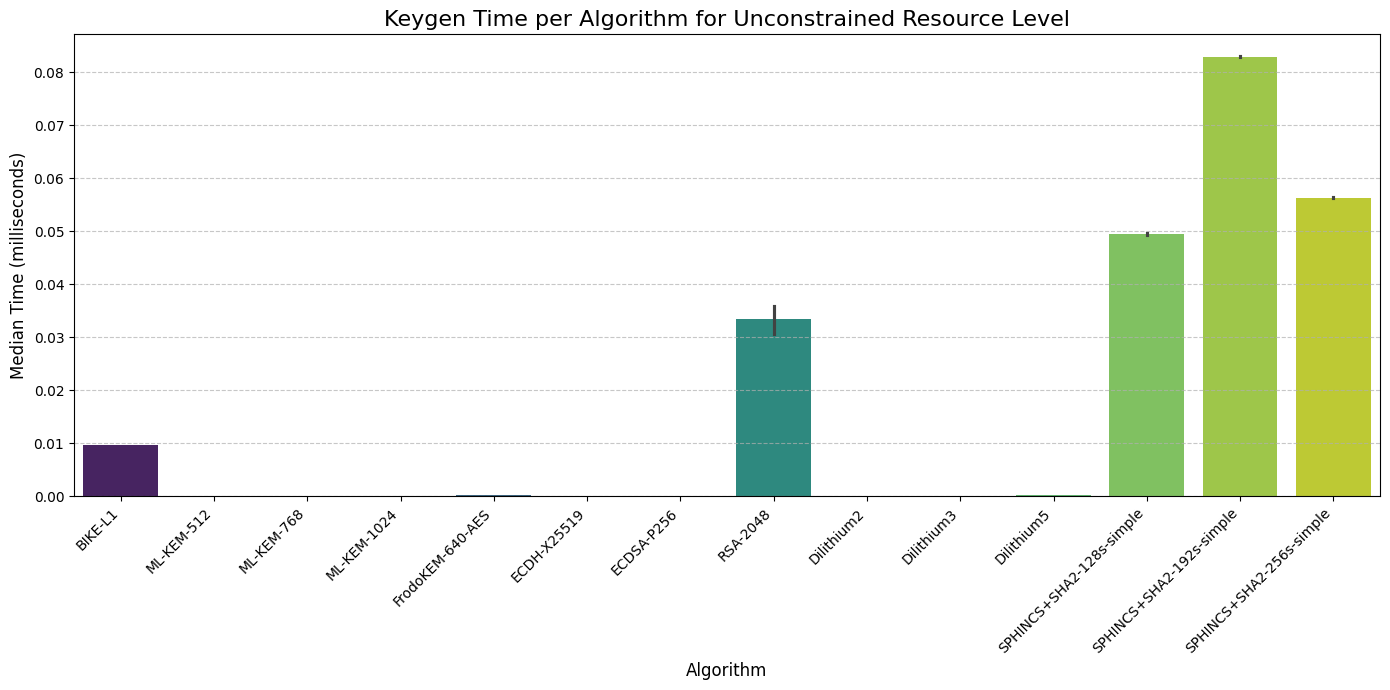

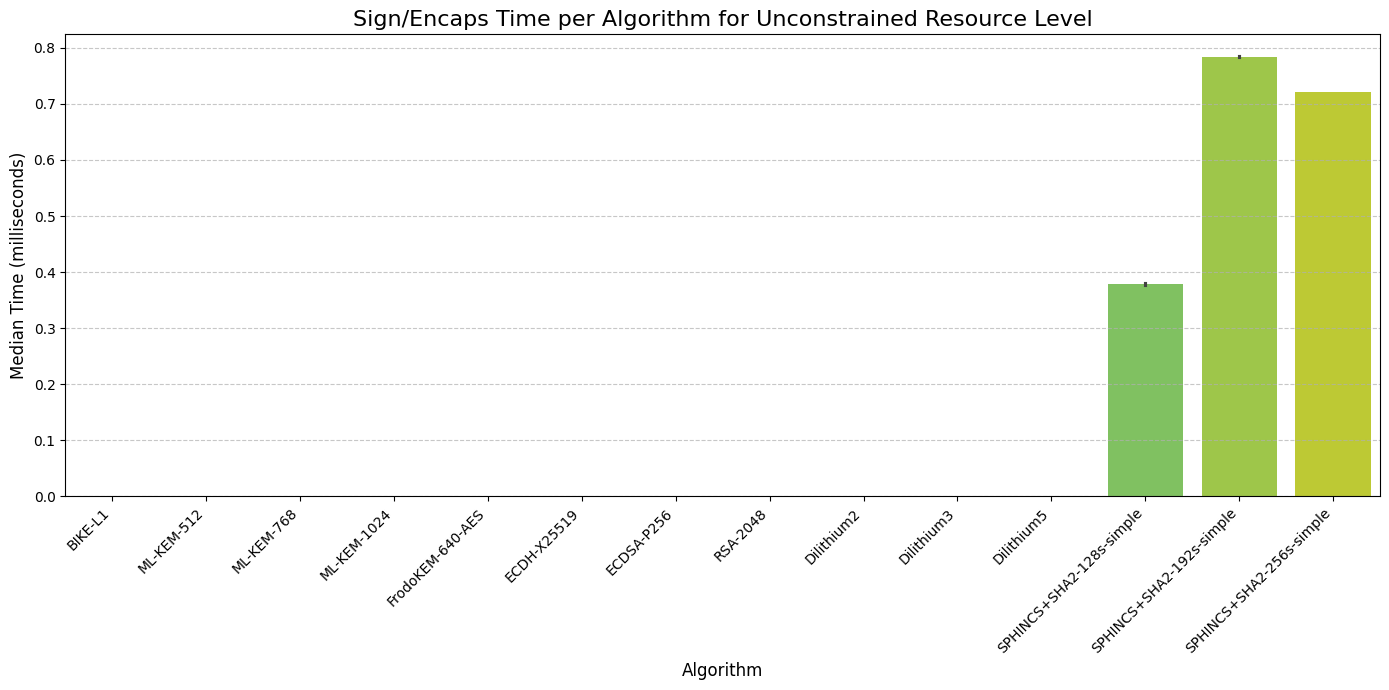

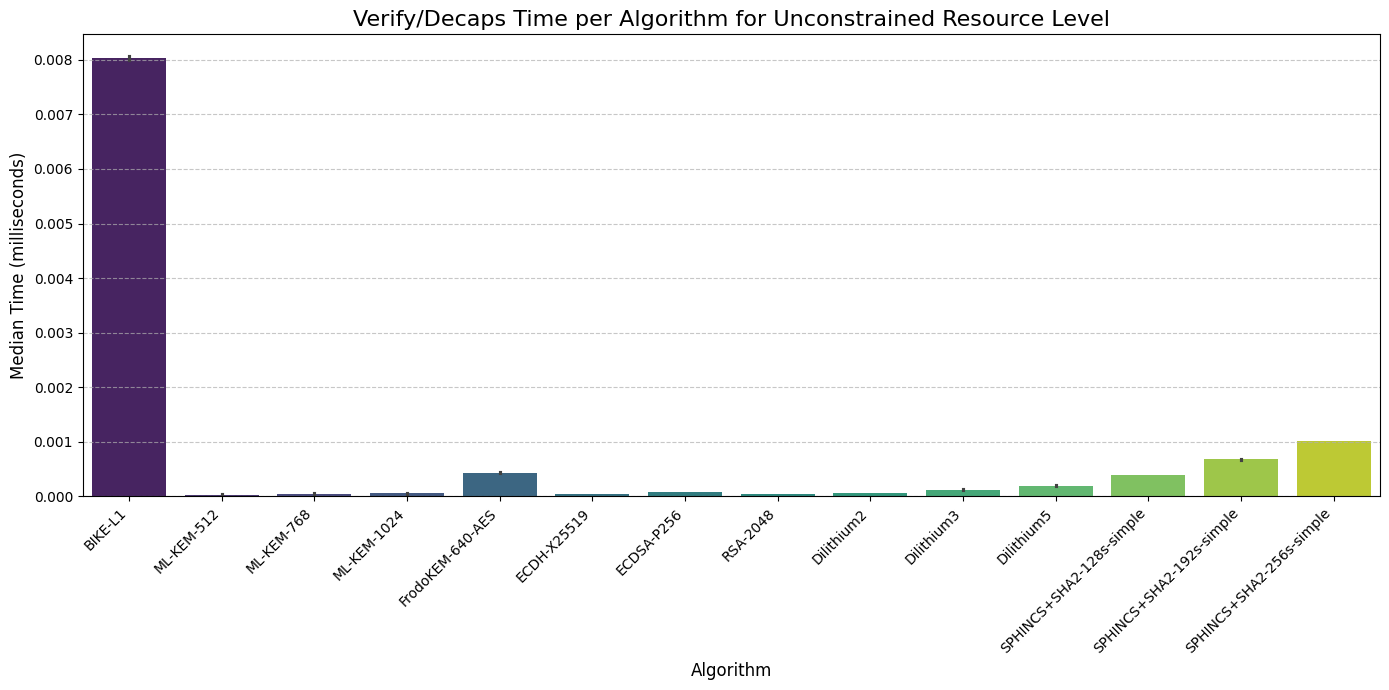

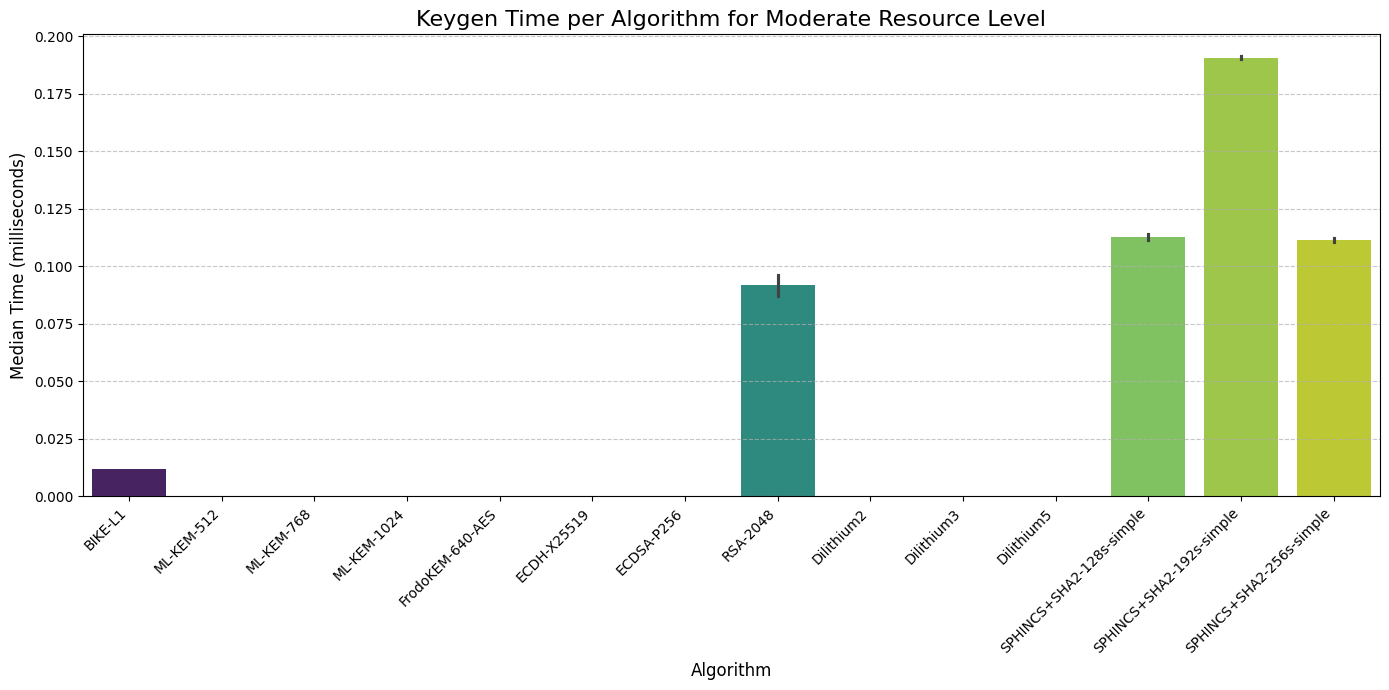

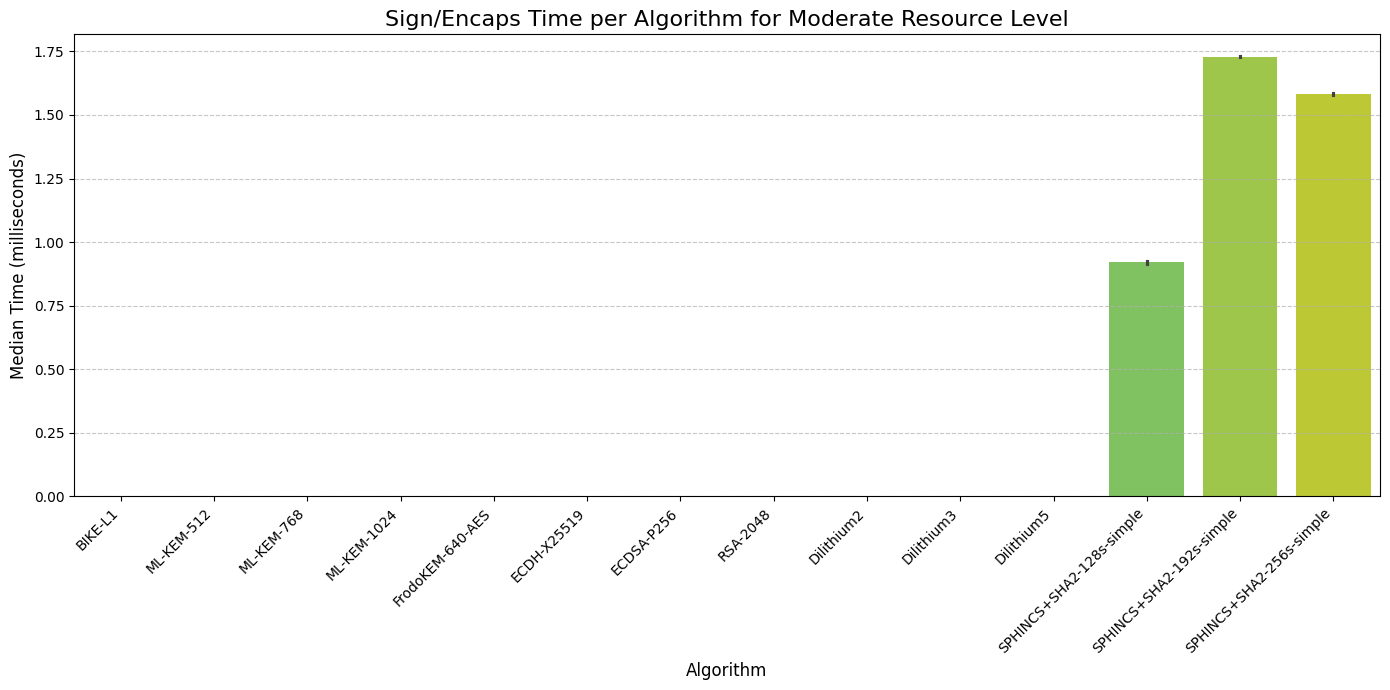

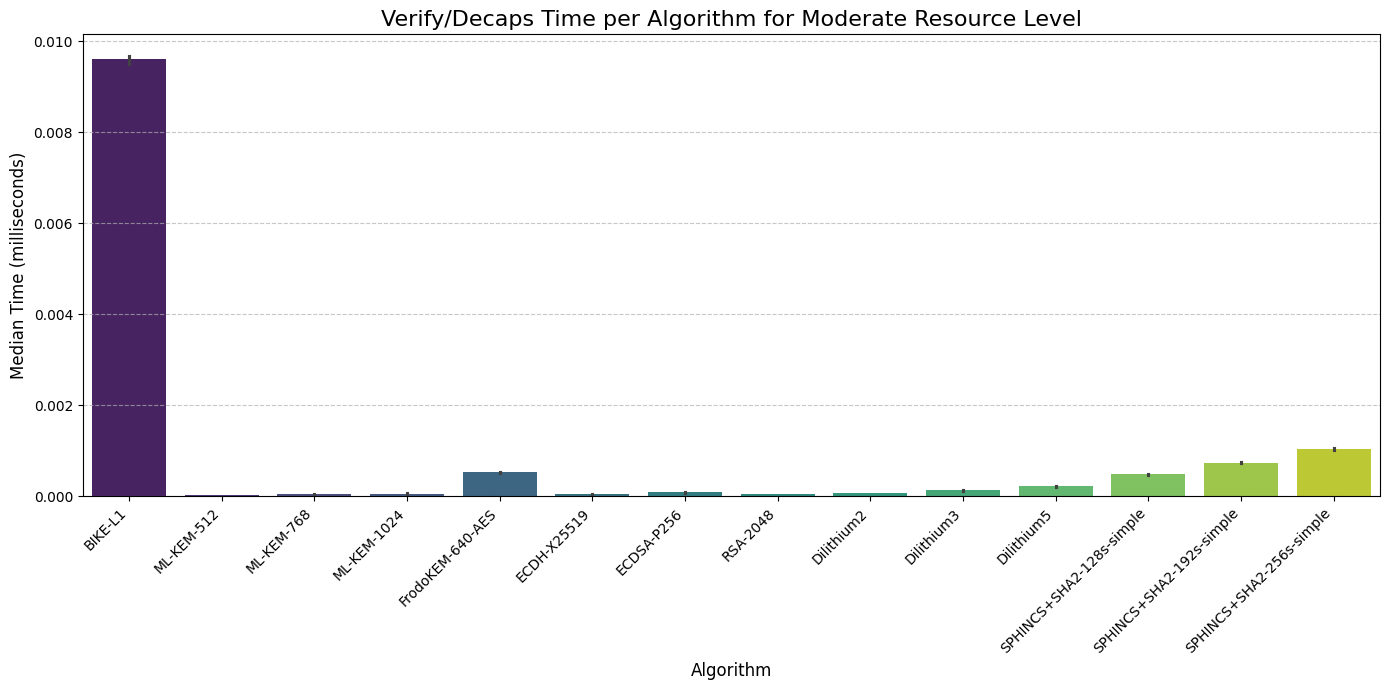

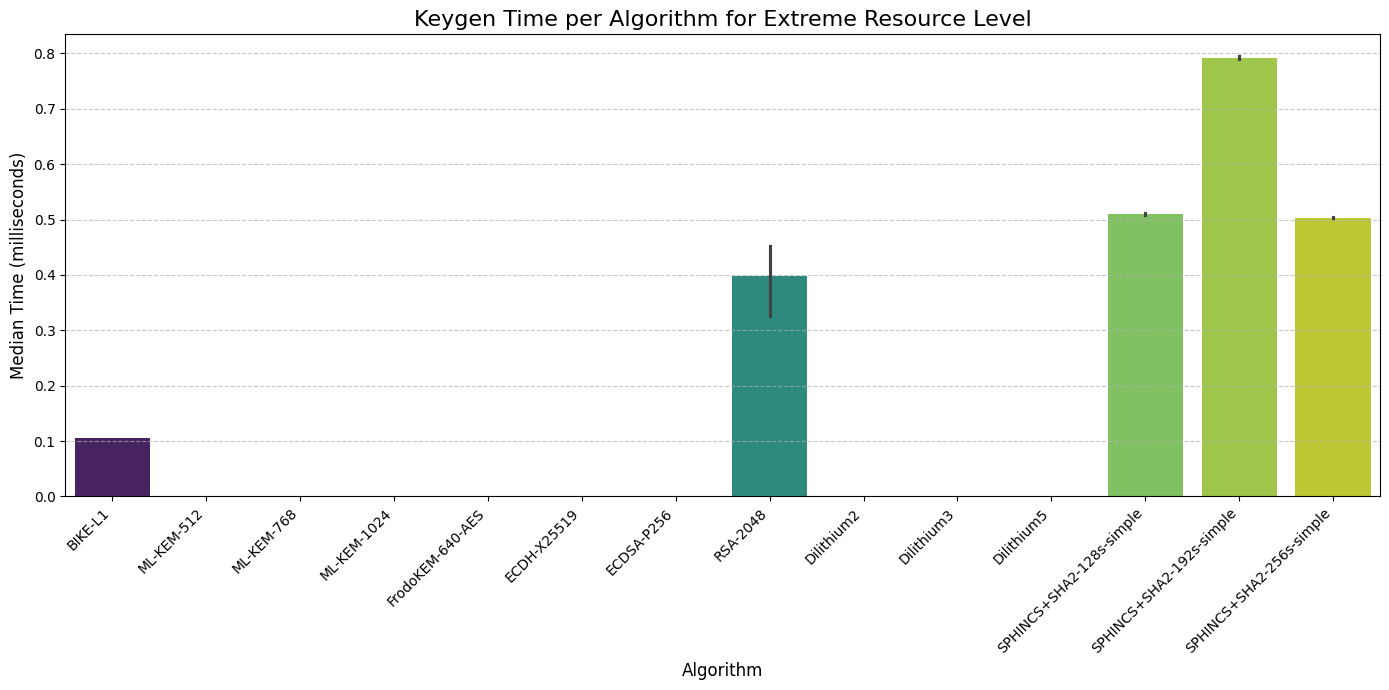

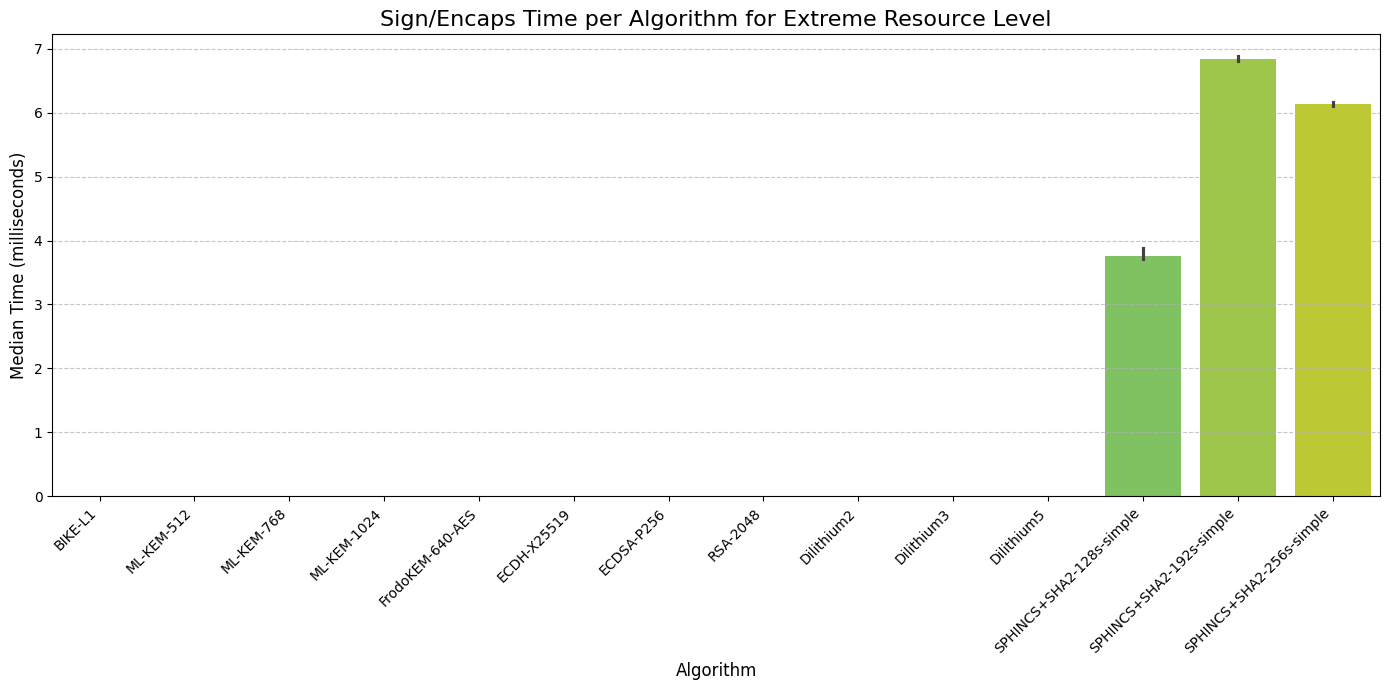

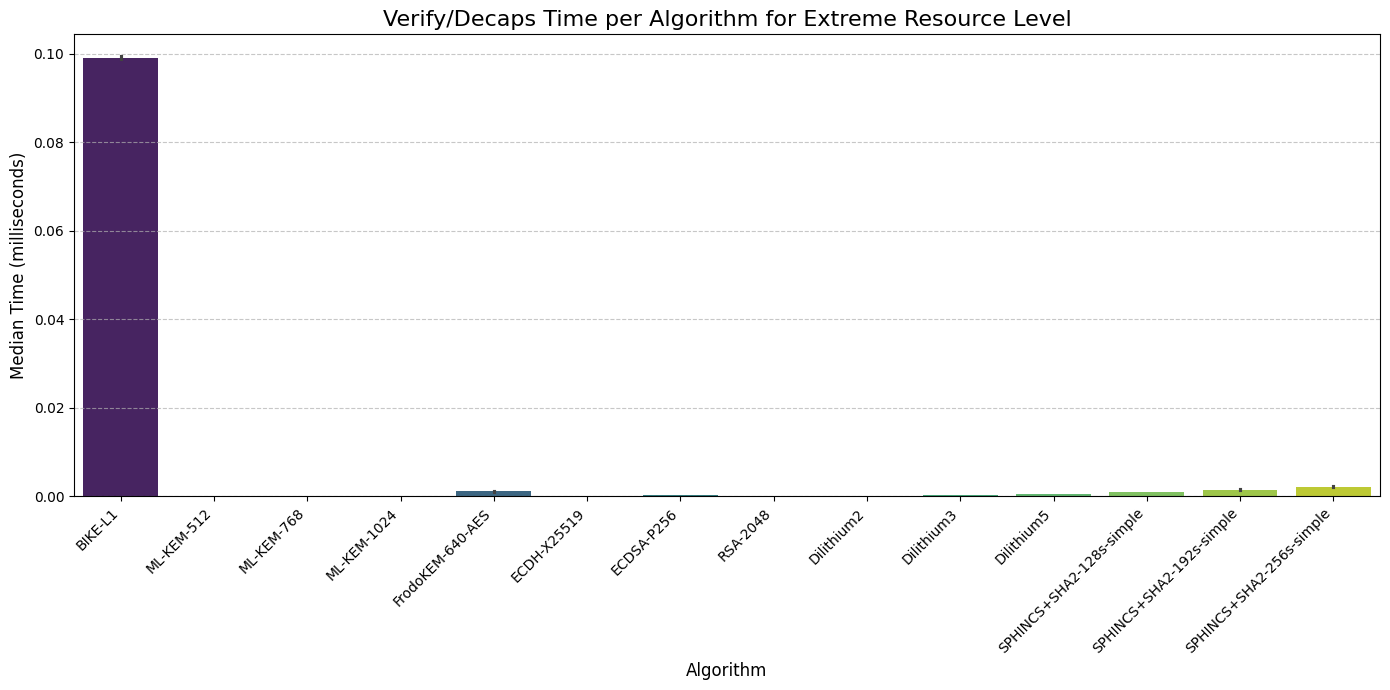

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Define the resource levels and the columns to plot
resource_levels = ['unconstrained', 'moderate', 'extreme']
operations = ['generate_median_time', 'encapsulate_median_time', 'decapsulate_median_time']

# Map operations to more readable labels for plotting
operation_labels = {
    'generate_median_time': 'Keygen Time',
    'encapsulate_median_time': 'Sign/Encaps Time',
    'decapsulate_median_time': 'Verify/Decaps Time'
}

# Loop through each resource level
for level in resource_levels:
    if level in dfs_pqc:
        df_level = dfs_pqc[level].copy()

        # Loop through each operation to create a separate chart
        for operation in operations:
            # Filter for the current operation and drop NaNs
            df_op = df_level[['algorithm', operation]].dropna()

            if df_op.empty:
                print(f"No data to plot for resource level '{level}' and operation '{operation}'. Skipping.")
                continue

            plt.figure(figsize=(14, 7))
            sns.barplot(data=df_op,
                        x='algorithm',
                        y=operation,
                        hue='algorithm',  # Assign 'algorithm' to hue as suggested by the warning
                        palette='viridis',
                        legend=False) # Set legend to False to avoid redundant legend

            op_label = operation_labels.get(operation, operation) # Get readable label or use original
            plt.title(f'{op_label} per Algorithm for {level.capitalize()} Resource Level', fontsize=16)
            plt.xlabel('Algorithm', fontsize=12)
            plt.ylabel('Median Time (milliseconds)', fontsize=12)
            plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate x-axis labels for better readability
            plt.yticks(fontsize=10)
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
    else:
        print(f"Data for resource level '{level}' not found in dfs_pqc. Skipping.")


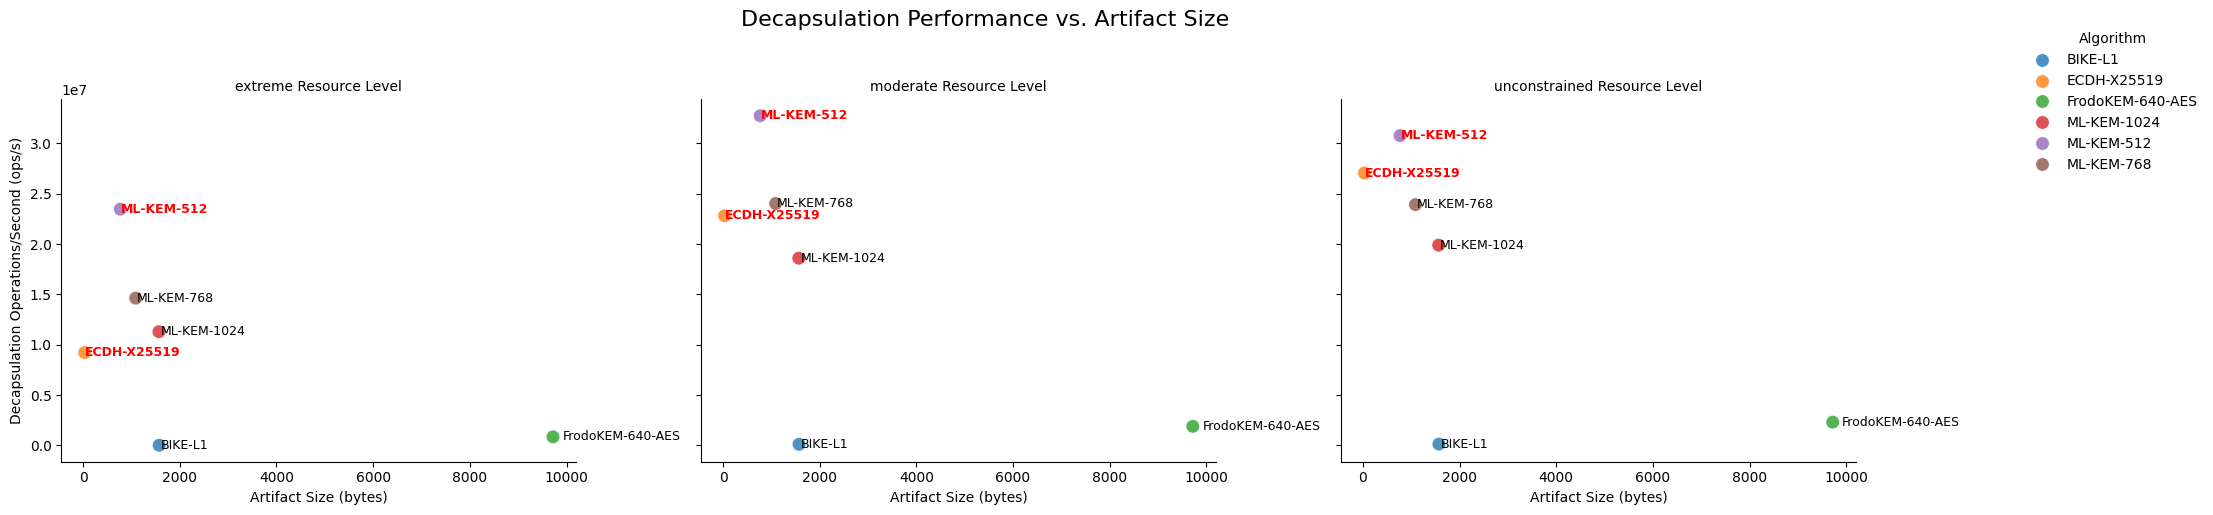


--- Pareto-optimal algorithms for Decapsulation vs Artifact Size ---
  Extreme Resource Level:
    - ML-KEM-512 (Ops/s: 23468947.07, Size: 768 bytes)
    - ECDH-X25519 (Ops/s: 9219788.69, Size: 32 bytes)
  Moderate Resource Level:
    - ML-KEM-512 (Ops/s: 32744168.04, Size: 768 bytes)
    - ECDH-X25519 (Ops/s: 22813866.01, Size: 32 bytes)
  Unconstrained Resource Level:
    - ML-KEM-512 (Ops/s: 30777139.54, Size: 768 bytes)
    - ECDH-X25519 (Ops/s: 27060025.81, Size: 32 bytes)


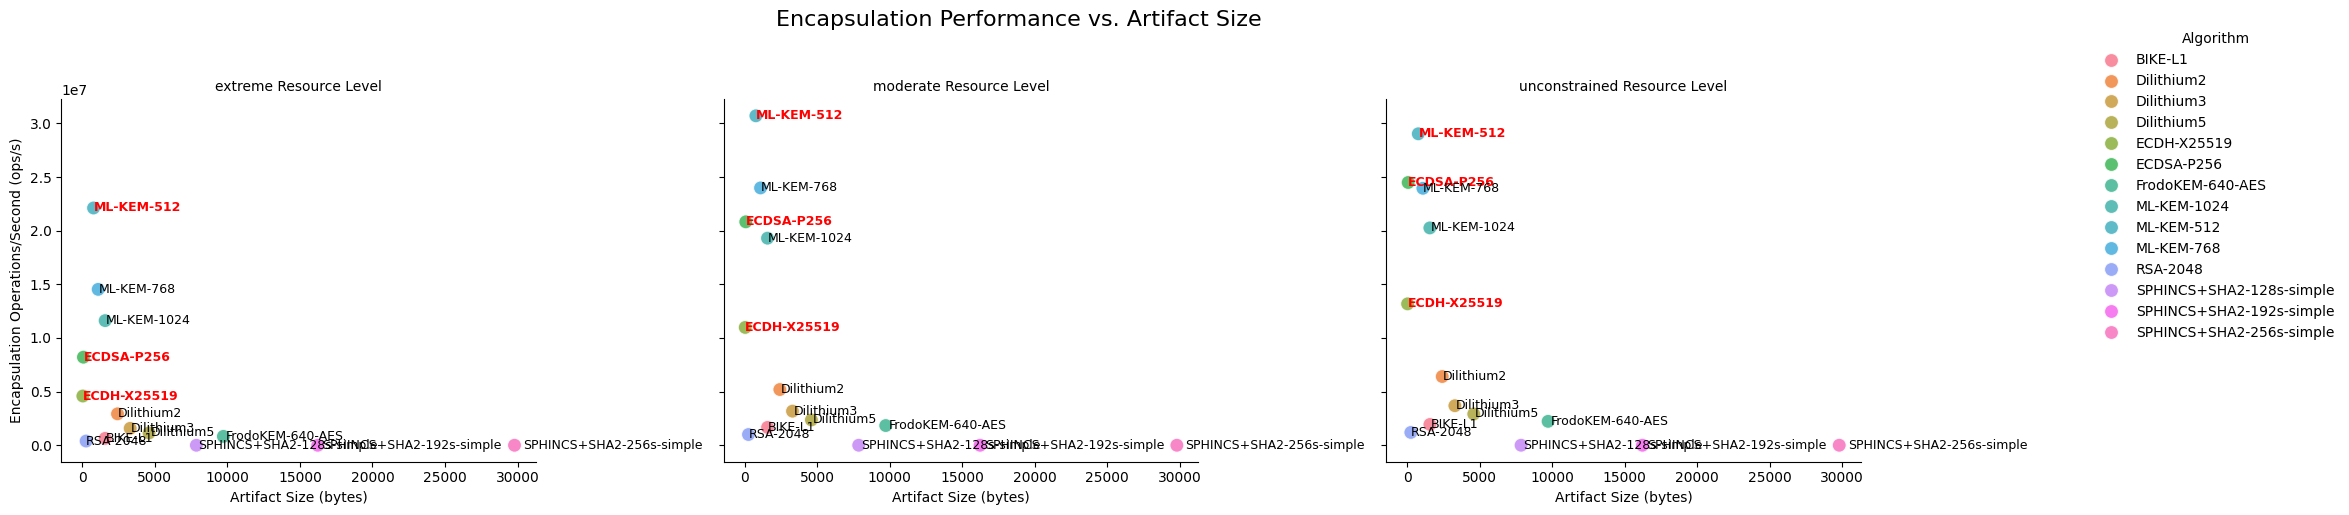


--- Pareto-optimal algorithms for Encapsulation vs Artifact Size ---
  Extreme Resource Level:
    - ML-KEM-512 (Ops/s: 22118770.82, Size: 768 bytes)
    - ECDSA-P256 (Ops/s: 8211829.26, Size: 71 bytes)
    - ECDH-X25519 (Ops/s: 4590574.65, Size: 32 bytes)
  Moderate Resource Level:
    - ML-KEM-512 (Ops/s: 30712834.25, Size: 768 bytes)
    - ECDSA-P256 (Ops/s: 20828031.06, Size: 71 bytes)
    - ECDH-X25519 (Ops/s: 10984761.78, Size: 32 bytes)
  Unconstrained Resource Level:
    - ML-KEM-512 (Ops/s: 29034544.24, Size: 768 bytes)
    - ECDSA-P256 (Ops/s: 24496092.11, Size: 71 bytes)
    - ECDH-X25519 (Ops/s: 13181365.86, Size: 32 bytes)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming dfs_pqc is already loaded as a dictionary of dataframes from previous cells

combined_df_scatter = pd.DataFrame()
resource_levels = ['unconstrained', 'moderate', 'extreme']

for level in resource_levels:
    if level in dfs_pqc:
        df_level = dfs_pqc[level].copy()
        df_level['resource_level'] = level
        combined_df_scatter = pd.concat([combined_df_scatter, df_level], ignore_index=True)

# Define algorithm types for specific artifact sizes
kem_algorithms = ['BIKE-L1', 'ML-KEM-512', 'ML-KEM-768', 'ML-KEM-1024', 'FrodoKEM-640-AES', 'ECDH-X25519']
sig_algorithms = ['ECDSA-P256', 'RSA-2048', 'Dilithium2', 'Dilithium3', 'Dilithium5', 'SPHINCS+SHA2-128s-simple', 'SPHINCS+SHA2-192s-simple', 'SPHINCS+SHA2-256s-simple']

# Create a column for artifact size based on operation and algorithm type
def get_artifact_size(row, op_time_col):
    if op_time_col == 'generate_median_time':
        return row['pk_size'] if 'pk_size' in row else pd.NA
    elif op_time_col == 'encapsulate_median_time':
        return row['ciphertext_size'] if 'ciphertext_size' in row else pd.NA
    elif op_time_col == 'decapsulate_median_time':
        if row['algorithm'] in kem_algorithms:
            return row['ciphertext_size'] if 'ciphertext_size' in row else pd.NA
        elif row['algorithm'] in sig_algorithms:
            return row['signature_size'] if 'signature_size' in row else pd.NA
    return pd.NA # Return Not Applicable if no matching size is found

# Calculate ops/s for each relevant operation and add artifact size
plot_data = []

# List of operations to analyze
operations_to_analyze = ['generate_median_time', 'encapsulate_median_time', 'decapsulate_median_time']

for index, row in combined_df_scatter.iterrows():
    for op_time_col in operations_to_analyze:
        # Check if the operation time exists and is not zero
        if pd.notna(row[op_time_col]) and row[op_time_col] > 0:
            # Calculate ops/s (assuming median_time is in ms, convert to seconds)
            ops_per_sec = 1 / (row[op_time_col] / 1000)

            # Determine the appropriate artifact size for this operation and algorithm
            artifact_size = get_artifact_size(row, op_time_col)

            # Only add to plot_data if both ops/s and artifact_size are valid
            if pd.notna(artifact_size) and pd.notna(ops_per_sec):
                plot_data.append({
                    'algorithm': row['algorithm'],
                    'resource_level': row['resource_level'],
                    'operation': op_time_col.replace('_median_time', ''),
                    'ops_per_sec': ops_per_sec,
                    'artifact_size_bytes': artifact_size
                })

df_plot = pd.DataFrame(plot_data)

# Aggregate data by algorithm, resource_level, and operation to get mean performance
# This makes sure each algorithm-operation pair has one point per resource level
df_plot_aggregated = df_plot.groupby(['algorithm', 'resource_level', 'operation']).mean().reset_index()

# Filter out rows with NaN values for plotting metrics
df_plot_aggregated.dropna(inplace=True)

# Map operation names to more readable labels for titles
operation_display_names = {
    'generate': 'Keygen',
    'encapsulate': 'Encapsulation',
    'decapsulate': 'Decapsulation'
}

# --- Function to find Pareto-optimal points ---
def find_pareto_optimal(df, x_col, y_col):
    """
    Finds Pareto-optimal points from a DataFrame.
    Assumes higher Y (ops/s) is better and lower X (size) is better.
    """
    pareto_points = []
    # Sort by Y (descending) and X (ascending) to speed up comparison
    df_sorted = df.sort_values(by=[y_col, x_col], ascending=[False, True])

    for i, (idx, row) in enumerate(df_sorted.iterrows()):
        is_dominated = False
        for j, (idx_other, row_other) in enumerate(df_sorted.iterrows()):
            if i == j:
                continue

            # 'other' dominates 'current' if:
            # (other_y >= current_y AND other_x <= current_x)
            # AND (other_y > current_y OR other_x < current_x) (at least one strictly better)
            if (row_other[y_col] >= row[y_col] and row_other[x_col] <= row[x_col]) and \
               (row_other[y_col] > row[y_col] or row_other[x_col] < row[x_col]):
                is_dominated = True
                break
        if not is_dominated:
            pareto_points.append(idx)

    return df.loc[pareto_points]

# --- Plotting and Pareto-optimal identification for each operation ---
for op_name in df_plot_aggregated['operation'].unique():
    df_op_data = df_plot_aggregated[df_plot_aggregated['operation'] == op_name].copy()

    if df_op_data.empty:
        print(f"Skipping plot for operation '{op_name}': No valid data.")
        continue

    # Create a FacetGrid for resource levels
    g = sns.FacetGrid(df_op_data, col='resource_level', col_wrap=3, height=5, aspect=1.2)

    # Map scatter plot to the facet grid
    g.map_dataframe(sns.scatterplot, x='artifact_size_bytes', y='ops_per_sec', hue='algorithm', s=100, alpha=0.8)

    # Add text labels for each algorithm
    def add_labels(x, y, hue, **kwargs):
        df_facet = kwargs.pop('data')
        # Identify pareto optimal points within this specific facet's data
        pareto_df_facet = find_pareto_optimal(df_facet, x, y)

        for i, row in df_facet.iterrows():
            text_color = 'red' if row['algorithm'] in pareto_df_facet['algorithm'].values else 'black'
            font_weight = 'bold' if row['algorithm'] in pareto_df_facet['algorithm'].values else 'normal'
            plt.text(row[x] * 1.02, row[y], row[hue],
                     fontsize=9, ha='left', va='center', color=text_color, fontweight=font_weight)

    g.map_dataframe(add_labels, x='artifact_size_bytes', y='ops_per_sec', hue='algorithm')

    op_title = operation_display_names.get(op_name, op_name.capitalize())
    g.set_axis_labels('Artifact Size (bytes)', f'{op_title} Operations/Second (ops/s)')
    g.set_titles(col_template='{col_name} Resource Level')
    g.add_legend(title='Algorithm', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.suptitle(f'{op_title} Performance vs. Artifact Size', y=1.02, fontsize=16) # Overall title
    g.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
    plt.show()

    # Print Pareto-optimal algorithms for each resource level and operation
    print(f"\n--- Pareto-optimal algorithms for {op_title} vs Artifact Size ---")
    for level in df_op_data['resource_level'].unique():
        df_level_op_data = df_op_data[df_op_data['resource_level'] == level].copy()
        if not df_level_op_data.empty:
            pareto_df = find_pareto_optimal(df_level_op_data, 'artifact_size_bytes', 'ops_per_sec')
            print(f"  {level.capitalize()} Resource Level:")
            if not pareto_df.empty:
                for _, row in pareto_df.iterrows():
                    print(f"    - {row['algorithm']} (Ops/s: {row['ops_per_sec']:.2f}, Size: {row['artifact_size_bytes']:.0f} bytes)")
            else:
                print("    No Pareto-optimal algorithms found (possibly due to insufficient data or all points are dominated).")
        else:
            print(f"  No data for {level.capitalize()} Resource Level to determine Pareto-optimal points.")


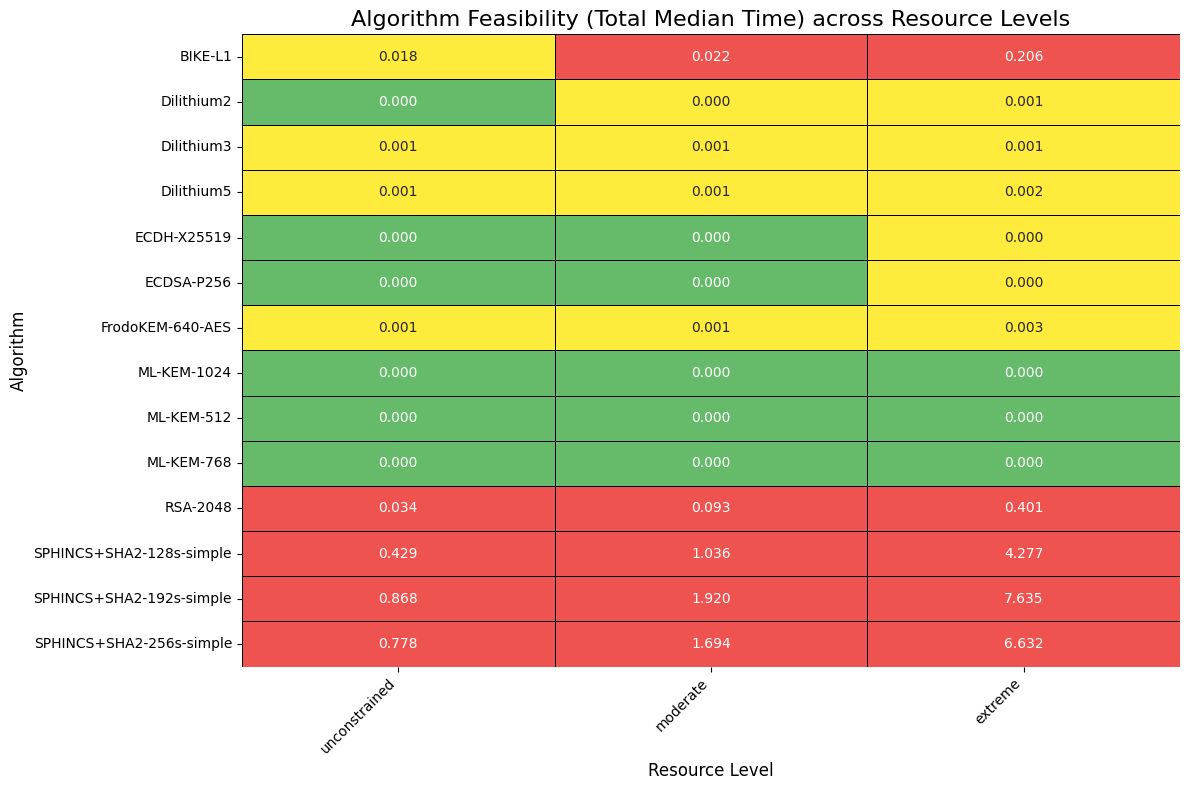

Feasibility thresholds (Total Median Time in milliseconds):
  Green (Highly Feasible): <= 0.0003 ms
  Yellow (Moderately Feasible): > 0.0003 ms and <= 0.0185 ms
  Red (Less Feasible): > 0.0185 ms


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assuming dfs_pqc and resource_levels are defined from previous cells
# dfs_pqc: dictionary of DataFrames, one for each resource level
# resource_levels: list of resource level names (e.g., ['unconstrained', 'moderate', 'extreme'])

operations = ['generate_median_time', 'encapsulate_median_time', 'decapsulate_median_time']
all_aggregated_data = []

for level in resource_levels:
    if level in dfs_pqc:
        df_level = dfs_pqc[level].copy()

        # Group by algorithm to get the average median time for each operation across repetitions
        # This aggregates the performance for each algorithm within the given resource level
        aggregated_performance = df_level.groupby('algorithm')[operations].mean().reset_index()

        # Calculate a combined performance metric (e.g., sum of median times)
        # Lower sum indicates better overall performance (higher feasibility)
        aggregated_performance['total_median_time'] = aggregated_performance[operations].sum(axis=1)
        aggregated_performance['resource'] = level
        all_aggregated_data.append(aggregated_performance[['algorithm', 'resource', 'total_median_time']])

if not all_aggregated_data:
    print("No data available to create the heatmap.")
else:
    df_combined_performance = pd.concat(all_aggregated_data, ignore_index=True)

    # Pivot the table to create the algorithm (row) x resource (col) matrix
    heatmap_matrix = df_combined_performance.pivot_table(index='algorithm',
                                                         columns='resource',
                                                         values='total_median_time')

    # Reorder columns to a logical sequence for display
    heatmap_matrix = heatmap_matrix[resource_levels]

    # --- Categorize feasibility into Green/Yellow/Red based on quantiles ---
    # Lower total_median_time means higher feasibility.
    # So, lower values will be green, higher values will be red.

    # Get all total_median_time values for categorization
    all_times = df_combined_performance['total_median_time'].dropna()

    if all_times.empty or len(all_times.unique()) < 3: # Need at least 3 unique values for 3 categories
        print("Not enough unique time data points for quantile-based categorization. Cannot create heatmap.")
    else:
        # Define thresholds using quantiles
        low_threshold = all_times.quantile(0.33)
        high_threshold = all_times.quantile(0.66)

        # Create a DataFrame for categorical labels and another for numeric values for annotation
        feasibility_labels_matrix = pd.DataFrame(index=heatmap_matrix.index, columns=heatmap_matrix.columns)
        numeric_annotation_matrix = pd.DataFrame(index=heatmap_matrix.index, columns=heatmap_matrix.columns)

        for col in heatmap_matrix.columns:
            for idx in heatmap_matrix.index:
                time_val = heatmap_matrix.loc[idx, col]
                numeric_annotation_matrix.loc[idx, col] = f'{time_val:.3f}' if pd.notna(time_val) else ''

                if pd.isna(time_val):
                    feasibility_labels_matrix.loc[idx, col] = np.nan # Use NaN for missing data, will be greyed out
                elif time_val <= low_threshold:
                    feasibility_labels_matrix.loc[idx, col] = 0 # Green category
                elif time_val <= high_threshold:
                    feasibility_labels_matrix.loc[idx, col] = 1 # Yellow category
                else:
                    feasibility_labels_matrix.loc[idx, col] = 2 # Red category

        # Define custom colormap for Green, Yellow, Red
        colors = ['#66BB6A', '#FFEB3B', '#EF5350'] # Green, Yellow, Red (Material Design A400 palette)
        cmap = plt.cm.colors.ListedColormap(colors)

        # Create a custom Normalization for discrete categories
        bounds = [-0.5, 0.5, 1.5, 2.5] # Boundaries for 3 categories (0, 1, 2)
        norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

        plt.figure(figsize=(12, 8))
        sns.heatmap(feasibility_labels_matrix.astype(float),
                    cmap=cmap,
                    norm=norm,
                    annot=numeric_annotation_matrix,
                    fmt='s', # String formatter for annotation
                    linewidths=.5,
                    linecolor='black',
                    cbar=False) # No colorbar needed for discrete categories, labels are clearer

        plt.title('Algorithm Feasibility (Total Median Time) across Resource Levels', fontsize=16)
        plt.xlabel('Resource Level', fontsize=12)
        plt.ylabel('Algorithm', fontsize=12)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(rotation=0, fontsize=10)
        plt.tight_layout()
        plt.show()

        print(f"Feasibility thresholds (Total Median Time in milliseconds):")
        print(f"  Green (Highly Feasible): <= {low_threshold:.4f} ms")
        print(f"  Yellow (Moderately Feasible): > {low_threshold:.4f} ms and <= {high_threshold:.4f} ms")
        print(f"  Red (Less Feasible): > {high_threshold:.4f} ms")


Skipping dimension 'pk_size' for radar chart as it's not available or contains only nulls in the data.
Skipping dimension 'signature_size' for radar chart as it's not available or contains only nulls in the data.
Skipping dimension 'ram_usage_bytes' for radar chart as it's not available or contains only nulls in the data.


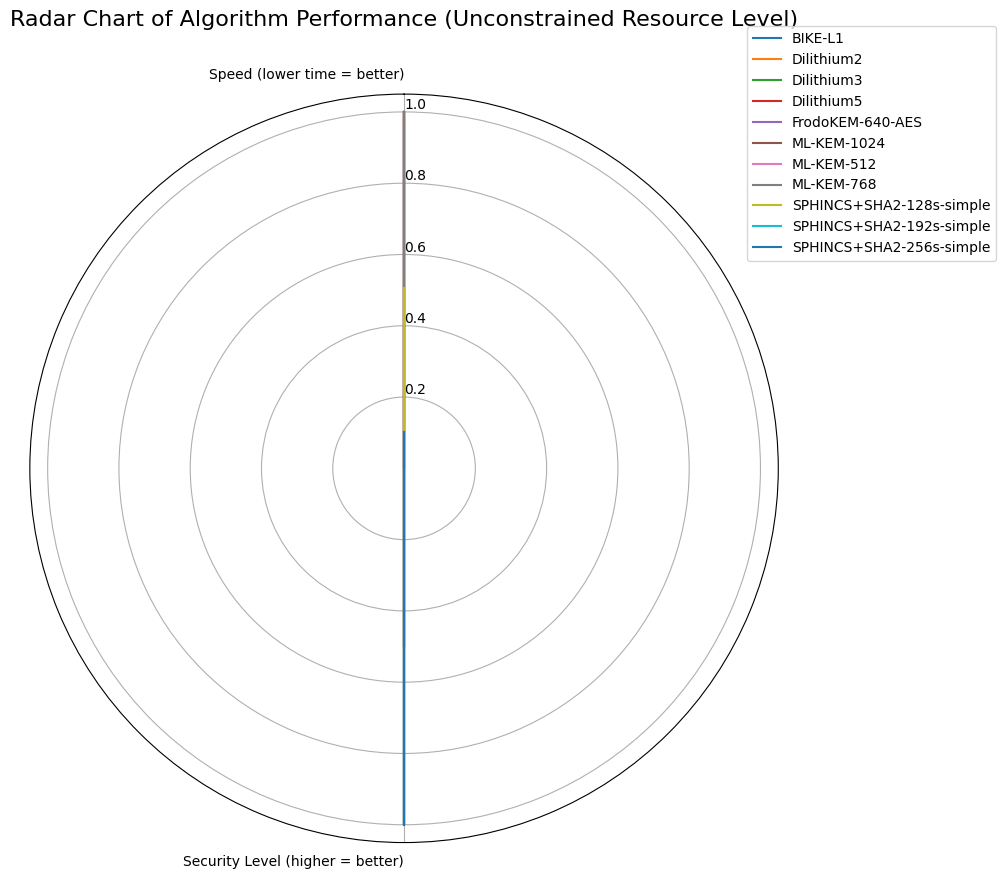

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Select relevant data for 'unconstrained' resource level
# Speed: total_median_time (lower is better)
# df_combined_performance contains 'algorithm', 'resource', 'total_median_time'
df_speed = df_combined_performance[df_combined_performance['resource'] == 'unconstrained'][['algorithm', 'total_median_time']]

# Define the static metrics we are looking for
desired_static_metric_names = ['pk_size', 'signature_size', 'ram_usage_bytes']
# Filter for columns that actually exist in the dfs_pqc['unconstrained'] DataFrame
existing_static_metric_cols = [col for col in desired_static_metric_names if col in dfs_pqc['unconstrained'].columns]

df_static_metrics = pd.DataFrame({'algorithm': dfs_pqc['unconstrained']['algorithm'].unique()}) # Start with unique algorithms

if existing_static_metric_cols:
    temp_df = dfs_pqc['unconstrained'][['algorithm'] + existing_static_metric_cols]
    # Average across repetitions for these static metrics (though they often don't vary by repetition)
    temp_df = temp_df.groupby('algorithm').mean().reset_index()
    df_static_metrics = pd.merge(df_static_metrics, temp_df, on='algorithm', how='left')
else:
    print("Warning: None of the desired static metrics (pk_size, signature_size, ram_usage_bytes) were found in the 'unconstrained' sheet.")

# Security Level (re-define for robustness if not in scope)
security_level_map = {
    'ML-KEM-512': 1, 'BIKE-L1': 1, 'FrodoKEM-640-AES': 1,
    'ML-KEM-768': 3, 'Dilithium2': 3, 'SPHINCS+SHA2-128s-simple': 3,
    'ML-KEM-1024': 5, 'Dilithium3': 5, 'Dilithium5': 5,
    'SPHINCS+SHA2-192s-simple': 5, 'SPHINCS+SHA2-256s-simple': 5
}
df_security = pd.DataFrame(security_level_map.items(), columns=['algorithm', 'security_level'])

# 2. Merge into a single DataFrame
df_radar = pd.merge(df_speed, df_static_metrics, on='algorithm', how='left')
df_radar = pd.merge(df_radar, df_security, on='algorithm', how='left')

# Drop algorithms that are not in the security map (e.g., classical ones, if any remain after merge)
df_radar.dropna(subset=['security_level'], inplace=True)
df_radar['security_level'] = df_radar['security_level'].astype(int)

# 3. Handle signature_size for KEMs if 'signature_size' is an existing metric
if 'signature_size' in df_radar.columns:
    # KEMs (Key Encapsulation Mechanisms) do not have a signature_size.
    # For a radar chart with 'sig size' axis for ALL algorithms, we treat `signature_size` for KEMs as 0.
    # This will implicitly mean 'no signature' and when normalized (lower is better), it will yield a high score.
    # This will be explained in the interpretation.
    df_radar['signature_size'] = df_radar['signature_size'].fillna(0)

# Define the dimensions and labels for the radar chart dynamically
dimensions = ['total_median_time']
labels = ['Speed (lower time = better)']
lower_is_better = ['total_median_time']

# Add only the static metrics that are actually present in df_radar and have non-null data
for col in desired_static_metric_names:
    if col in df_radar.columns and not df_radar[col].isnull().all():
        dimensions.append(col)
        if col == 'pk_size':
            labels.append('Key Size (lower = better)')
        elif col == 'signature_size':
            labels.append('Sig Size (lower = better)')
        elif col == 'ram_usage_bytes':
            labels.append('Memory (lower = better)')
        lower_is_better.append(col)
    else:
        print(f"Skipping dimension '{col}' for radar chart as it's not available or contains only nulls in the data.")

dimensions.append('security_level')
labels.append('Security Level (higher = better)')

# Check if there are enough dimensions to plot a radar chart meaningfully
if len(dimensions) < 3: # Radar charts typically need at least 3 dimensions to be visually distinct from a line
    print(f"Warning: Only {len(dimensions)} dimensions available for the radar chart. A standard radar chart typically requires at least 3 dimensions. The plot might appear as a simple line graph.")

# 4. Normalize data (0-1 range)
normalized_df = df_radar[['algorithm']].copy()
for dim in dimensions:
    min_val = df_radar[dim].min()
    max_val = df_radar[dim].max()
    # Handle cases where min_val == max_val to avoid division by zero
    if max_val == min_val:
        normalized_df[dim] = 0.5 # Assign a neutral value if all values are the same
    else:
        normalized_df[dim] = (df_radar[dim] - min_val) / (max_val - min_val)
        if dim in lower_is_better:
            normalized_df[dim] = 1 - normalized_df[dim] # Invert score for 'lower is better' metrics

# Number of variables
num_vars = len(dimensions)

# Calculate angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Complete the loop

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Plot each algorithm
for i, row in normalized_df.iterrows():
    values = row[dimensions].tolist()
    values += values[:1] # Complete the loop
    ax.plot(angles, values, label=row['algorithm'], linewidth=1.5)
    ax.fill(angles, values, alpha=0.1)

# Set up the plot
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_rticks([0.2, 0.4, 0.6, 0.8, 1.0]) # Radial ticks
ax.set_rlabel_position(0)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10, rotation=45, ha='right') # Rotate labels for readability
ax.set_title('Radar Chart of Algorithm Performance (Unconstrained Resource Level)', size=16, y=1.08)

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()